#**Deepfake Image Detection Using Transfer Learning and Optimization Techniques for Enhanced Classification Performance**

Deep Learning Course (AI3202)

**Team Members:**


*   Linda Alzahrani | 445004868
*   Jenan Bajawi | 445000496


*   Raghad Alzahrani | 445000460
*   Basmah Mohammed | 445013838


*   Dina Yousef | 445013898


---

#**About the project**

This project focuses on deepfake image detection using a deep learning model based on ResNet50 and transfer learning techniques. Several enhancement methods were evaluated to improve classification performance, including augmentation, optimization strategies, and calibration techniques.

##**Dataset**

The Deepfake and Real Images dataset from Kaggle, containing face images divided into two categories: Fake and Real images for binary deepfake classification.

#**Setup & Installation**


In [1]:
# Import libraries
import os
import glob
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
from PIL import Image
from torchvision.datasets import ImageFolder
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np
import random
import seaborn as sns
import torch
import torch.nn as nn
import torchvision.models as models
from tqdm import tqdm
import torch.optim as optim

###**Data Loading & Preprocessing**


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("manjilkarki/deepfake-and-real-images")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'deepfake-and-real-images' dataset.
Path to dataset files: /kaggle/input/deepfake-and-real-images


In [3]:
for root, dirs, files in os.walk(path):
    print(root)

/kaggle/input/deepfake-and-real-images
/kaggle/input/deepfake-and-real-images/Dataset
/kaggle/input/deepfake-and-real-images/Dataset/Validation
/kaggle/input/deepfake-and-real-images/Dataset/Validation/Fake
/kaggle/input/deepfake-and-real-images/Dataset/Validation/Real
/kaggle/input/deepfake-and-real-images/Dataset/Test
/kaggle/input/deepfake-and-real-images/Dataset/Test/Fake
/kaggle/input/deepfake-and-real-images/Dataset/Test/Real
/kaggle/input/deepfake-and-real-images/Dataset/Train
/kaggle/input/deepfake-and-real-images/Dataset/Train/Fake
/kaggle/input/deepfake-and-real-images/Dataset/Train/Real


In [4]:
import os

dataset_path = "/kaggle/input/deepfake-and-real-images/Dataset"

image_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.gif')

total_images = 0

for split in ['Train', 'Validation', 'Test']:

    split_path = os.path.join(dataset_path, split)

    print(f"\n===== {split.upper()} =====")

    split_total = 0

    for category in ['Fake', 'Real']:

        category_path = os.path.join(split_path, category)

        image_count = sum(
            file.lower().endswith(image_extensions)
            for file in os.listdir(category_path)
        )

        print(f"{category}: {image_count} images")

        split_total += image_count

    print(f"Total {split} images: {split_total}")

    total_images += split_total

print(f"\nTotal Images in Dataset: {total_images}")


===== TRAIN =====
Fake: 70001 images
Real: 70001 images
Total Train images: 140002

===== VALIDATION =====
Fake: 19641 images
Real: 19787 images
Total Validation images: 39428

===== TEST =====
Fake: 5492 images
Real: 5413 images
Total Test images: 10905

Total Images in Dataset: 190335


#**Baseline**

##Linda Alzahrani | 445004868

###**Data Preprocessing and Data Loaders**

In [5]:
# Define transformations for training data
# Includes resizing, augmentation, tensor conversion, and normalization
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),            # Resize images to 224x224
    transforms.RandomHorizontalFlip(),        # Randomly flip images for augmentation
    transforms.ToTensor(),                    # Convert image to tensor
    transforms.Normalize(                     # Normalize using ImageNet values
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Transformations for validation and test data (no augmentation)
transform_test = transforms.Compose([
    transforms.Resize((224, 224)),            # Resize images
    transforms.ToTensor(),                    # Convert to tensor
    transforms.Normalize(                     # Normalize images
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225])
])

train_dir = os.path.join(path, "Dataset/Train")
val_dir   = os.path.join(path, "Dataset/Validation")
test_dir  = os.path.join(path, "Dataset/Test")

train_dataset = ImageFolder(root=train_dir, transform=transform_train)
val_dataset   = ImageFolder(root=val_dir,   transform=transform_test)
test_dataset  = ImageFolder(root=test_dir,  transform=transform_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

# Check a batch of images
images, labels = next(iter(train_loader))
print(f"Batch shape: {images.shape}, Labels: {labels}")

Batch shape: torch.Size([32, 3, 224, 224]), Labels: tensor([1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1,
        1, 1, 1, 1, 0, 0, 0, 1])


In [6]:
total = len(train_dataset) + len(val_dataset) + len(test_dataset)

print("Train %:", len(train_dataset)/total * 100)
print("Val %:", len(val_dataset)/total * 100)
print("Test %:", len(test_dataset)/total * 100)

Train %: 73.55557306853704
Val %: 20.715055034544356
Test %: 5.729371896918591


###**Data Visualization**

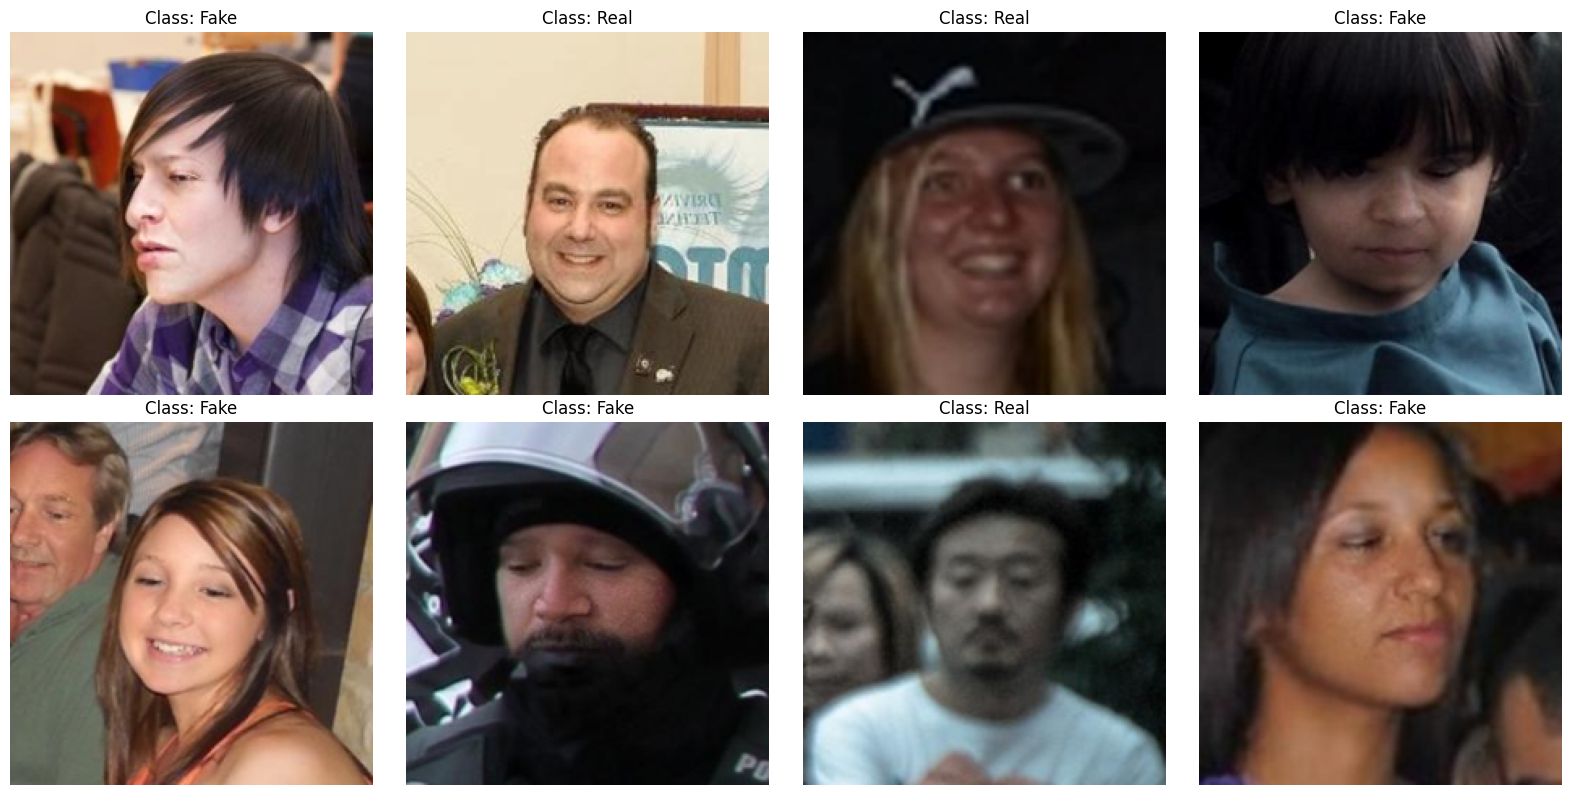

In [ ]:
# Define mean & std for denormalization (ResNet50 Preprocessing)
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

# Number of images to display
num_images = 8

# Randomly select indices
imgs_indices = random.sample(range(len(train_dataset)), num_images)

# Create figure (2 rows, 4 columns)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# Flatten axes array for easy looping
axes = axes.flatten()

for i in range(num_images):
    img, label = train_dataset[imgs_indices[i]]

    # Convert tensor to numpy
    img_np = img.numpy().transpose(1, 2, 0)

    # Denormalize
    img_np = std * img_np + mean
    img_np = np.clip(img_np, 0, 1)

    # Show image
    axes[i].imshow(img_np)
    axes[i].set_title(f'Class: {"Fake" if label == 0 else "Real"}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

###**Model Architecture (ResNet50 Baseline)**

In [ ]:
# Select device (GPU if available, otherwise CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load pretrained ResNet50 model (trained on ImageNet)
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

# Freeze all layers in the backbone for baseline training
for param in model.parameters():
    param.requires_grad = False

# Get number of input features from the final fully connected layer
num_features = model.fc.in_features

# Replace the final layer with a custom classifier
model.fc = nn.Sequential(
    nn.Dropout(0.5),            # Add dropout to reduce overfitting
    nn.Linear(num_features, 1)  # Binary classification output
)

# Move model to the selected device
model = model.to(device)


# Define loss function for binary classification
criterion = nn.BCEWithLogitsLoss()

# Define optimizer (only train the classifier layer)
optimizer = torch.optim.Adam(model.fc.parameters(), lr=0.001, weight_decay=1e-4)

# Print model architecture
print(model)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 182MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

###**Training Function**

In [ ]:
# Training function for one epoch
def train_one_epoch(model, dataloader, criterion, optimizer, device):

    model.train()   # Set model to training mode
    total_loss = 0
    correct = 0
    total = 0

    # Loop through batches in the dataloader
    for images, labels in tqdm(dataloader):

        # Move data to GPU/CPU
        images = images.to(device)
        labels = labels.to(device).float()

        # Forward pass
        outputs = model(images).view(-1)
        loss = criterion(outputs, labels)

        # Backpropagation
        optimizer.zero_grad()   # Clear previous gradients
        loss.backward()         # Compute gradients
        optimizer.step()        # Update model weights

        # Accumulate loss
        total_loss += loss.item()

        # Calculate predictions for accuracy
        predictions = torch.sigmoid(outputs) > 0.5  # Convert logits to binary prediction

        # Count correct predictions
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    # Compute average loss and accuracy for the epoch
    avg_loss = total_loss / len(dataloader)
    accuracy = 100 * correct / total

    return avg_loss, accuracy

###**Validation Function**

In [ ]:
# Validation function
def validate(model, dataloader, criterion, device):

    model.eval()    # Set model to evaluation mode
    total_loss = 0
    correct = 0
    total = 0

    # Lists to store predictions and labels for metrics
    all_preds = []
    all_labels = []

    # Disable gradient calculation (faster and saves memory)
    with torch.no_grad():

        # Loop through validation batches
        for images, labels in dataloader:

            # Move data to device
            images = images.to(device)
            labels = labels.to(device).float()

            # Forward pass
            outputs = model(images).view(-1)
            loss = criterion(outputs, labels)
            total_loss += loss.item()

            # Convert outputs to binary predictions
            predictions = torch.sigmoid(outputs) > 0.5

            # Calculate accuracy
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

            # Save predictions and labels for extra metrics
            all_preds.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Compute average loss and accuracy
    avg_loss = total_loss / len(dataloader)
    accuracy = 100 * correct / total

    return avg_loss, accuracy

###**Testing and Evaluation**

In [ ]:
# Evaluation function (used for test set)
def evaluate(model, dataloader, criterion, device):

    model.eval()    # Set model to evaluation mode
    total_loss = 0
    correct = 0
    total = 0

    # Lists to store all predictions and labels
    all_preds = []
    all_labels = []

    # Disable gradient calculation
    with torch.no_grad():

        # Loop through test batches
        for images, labels in dataloader:

            # Move data to device
            images = images.to(device)
            labels = labels.to(device).float()

            # Forward pass
            outputs = model(images).view(-1)
            loss = criterion(outputs, labels)
            total_loss += loss.item()

            # Convert outputs to binary predictions
            predictions = torch.sigmoid(outputs) > 0.5

            # Calculate accuracy
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

            # Store predictions and labels
            all_preds.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Compute average loss and accuracy
    avg_loss = total_loss / len(dataloader)
    accuracy = 100 * correct / total

    # Calculate evaluation metrics
    precision = precision_score(all_labels, all_preds)
    recall = recall_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)
    cm = confusion_matrix(all_labels, all_preds)

    return avg_loss, accuracy, precision, recall, f1, cm

###**Model Training**

In [ ]:
# Set number of training epochs
num_epochs = 10

# Lists to store training and validation metrics
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

# Training loop
for epoch in range(num_epochs):
    train_loss, train_accuracy = train_one_epoch(model, train_loader, criterion, optimizer, device)   # Train for one epoch
    val_loss, val_accuracy = validate(model, val_loader, criterion, device)                           # Validate after each epoch

    # Save metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    # Print epoch results
    print(f"Epoch {epoch+1}/{num_epochs}: "
          f"Train Loss={train_loss:.4f}, Train Accuracy={train_accuracy:.2f}%, "
          f"Val Loss={val_loss:.4f}, Val Accuracy={val_accuracy:.2f}%")

# Final evaluation on test set
test_loss, test_accuracy, precision, recall, f1, cm = evaluate(
    model, test_loader, criterion, device
)
# Print final test results
print("\nFinal Test Results:")
print("-"*30)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.2f}%")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print("-"*30)
print("Confusion Matrix:\n", cm)

100%|██████████| 4376/4376 [08:44<00:00,  8.34it/s]


Epoch 1/10: Train Loss=0.4820, Train Accuracy=76.89%, Val Loss=0.4248, Val Accuracy=80.25%


100%|██████████| 4376/4376 [08:54<00:00,  8.19it/s]


Epoch 2/10: Train Loss=0.4787, Train Accuracy=77.38%, Val Loss=0.4280, Val Accuracy=79.94%


100%|██████████| 4376/4376 [08:52<00:00,  8.22it/s]


...

Epoch 8/10: Train Loss=0.4794, Train Accuracy=77.31%, Val Loss=0.4345, Val Accuracy=79.71%


100%|██████████| 4376/4376 [08:52<00:00,  8.22it/s]


Epoch 9/10: Train Loss=0.4778, Train Accuracy=77.36%, Val Loss=0.4249, Val Accuracy=80.08%


100%|██████████| 4376/4376 [08:53<00:00,  8.20it/s]


Epoch 10/10: Train Loss=0.4781, Train Accuracy=77.32%, Val Loss=0.4371, Val Accuracy=79.49%

Final Test Results:
------------------------------
Test Loss: 0.6078
Test Accuracy: 69.12%
Precision: 0.7946
Recall: 0.5095
F1-Score: 0.6209
------------------------------
Confusion Matrix:
 [[4779  713]
 [2655 2758]]


In [ ]:
# Save Baseline Model
torch.save(model.state_dict(), "baseline_model.pth")
print("The Model is Saved")

The Model is Saved


#**Improvments**

##Dina Yousef | 445013898

###**Common Setup**

In [ ]:
# ============================================================
# COMMON SETUP
# This section imports the required libraries, defines the device,
# sets the training parameters, stores the baseline metrics,
# and creates the helper functions used in all experiments.
# ============================================================

import os
import copy
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torchvision.models as models
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torch.utils.data import DataLoader

from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

# Use GPU if available; otherwise, use CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Loss function for binary classification
criterion = nn.BCEWithLogitsLoss()

# Training configuration
EPOCHS = 10
BATCH_SIZE = 32

# Normalization values for ImageNet-pretrained ResNet50
mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]

# Baseline performance values used for comparison
baseline_metrics = {
    "loss": 0.6078,
    "accuracy": 69.12,
    "precision": 0.7946,
    "recall": 0.5095,
    "f1": 0.6209
}

# Convert experiment names into safe file names for saving plots
def slugify(text):
    return (
        text.lower()
        .replace(" ", "_")
        .replace(":", "")
        .replace("+", "plus")
        .replace("/", "_")
    )

# Build the baseline ResNet50 model
# The backbone is frozen and only the final classification layer is trained
def build_resnet50_model():
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

    # Freeze all pretrained layers
    for param in model.parameters():
        param.requires_grad = False

    # Replace the original FC layer with a binary classifier
    num_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(num_features, 1)
    )

    return model.to(device)

# Plot the confusion matrix for a given experiment
def plot_confusion_matrix(cm, title, save_path=None):
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Fake", "Real"],
        yticklabels=["Fake", "Real"]
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

# Plot training and validation loss/accuracy curves
def plot_curves(train_losses, val_losses, train_accs, val_accs, title_prefix, save_dir=None):
    # Loss curve
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, len(train_losses) + 1), train_losses, marker='o', label="Train Loss")
    plt.plot(range(1, len(val_losses) + 1), val_losses, marker='o', label="Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title(f"{title_prefix} - Loss Curve")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    if save_dir:
        plt.savefig(os.path.join(save_dir, f"{title_prefix}_loss.png"), dpi=300, bbox_inches="tight")

    plt.show()

    # Accuracy curve
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, len(train_accs) + 1), train_accs, marker='o', label="Train Accuracy")
    plt.plot(range(1, len(val_accs) + 1), val_accs, marker='o', label="Validation Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy (%)")
    plt.title(f"{title_prefix} - Accuracy Curve")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    if save_dir:
        plt.savefig(os.path.join(save_dir, f"{title_prefix}_accuracy.png"), dpi=300, bbox_inches="tight")

    plt.show()

# Create train, validation, and test loaders using the provided transform
def make_loaders(train_transform):
    # Validation and test use the same preprocessing without augmentation
    transform_test = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std)
    ])

    # Load datasets from the prepared folders
    train_dataset = ImageFolder(root=train_dir, transform=train_transform)
    val_dataset   = ImageFolder(root=val_dir, transform=transform_test)
    test_dataset  = ImageFolder(root=test_dir, transform=transform_test)

    # Create dataloaders for batching
    train_loader_local = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
    val_loader_local   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
    test_loader_local  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

    return train_loader_local, val_loader_local, test_loader_local

# Train the model, save the best weights, evaluate on the test set,
# and return all metrics and training history
def run_experiment(exp_name, model, train_loader_local, val_loader_local, test_loader_local, optimizer, plot_dir, save_best_path):
    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []

    # Track the best validation performance
    best_val_acc = -1.0
    best_val_loss = float("inf")
    best_state = copy.deepcopy(model.state_dict())
    best_epoch = 0

    print("\n" + "=" * 90)
    print(exp_name)
    print("=" * 90)

    # Training loop
    for epoch in range(EPOCHS):
        train_loss, train_acc = train_one_epoch(model, train_loader_local, criterion, optimizer, device)
        val_loss, val_acc = validate(model, val_loader_local, criterion, device)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        print(
            f"Epoch {epoch+1}/{EPOCHS} | "
            f"Train Loss={train_loss:.4f}, Train Acc={train_acc:.2f}% | "
            f"Val Loss={val_loss:.4f}, Val Acc={val_acc:.2f}%"
        )

        # Save the best model based on validation accuracy
        if (val_acc > best_val_acc) or (val_acc == best_val_acc and val_loss < best_val_loss):
            best_val_acc = val_acc
            best_val_loss = val_loss
            best_epoch = epoch + 1
            best_state = copy.deepcopy(model.state_dict())
            torch.save(best_state, save_best_path)
            print(f"  -> Best weights saved: {save_best_path}")

    # Restore best weights before final test evaluation
    model.load_state_dict(best_state)

    # Final test evaluation
    test_loss, test_accuracy, precision, recall, f1, cm = evaluate(model, test_loader_local, criterion, device)

    print("\nFinal Test Results:")
    print("-" * 60)
    print(f"Best Epoch    : {best_epoch}")
    print(f"Test Loss     : {test_loss:.4f}")
    print(f"Test Accuracy : {test_accuracy:.2f}%")
    print(f"Precision     : {precision:.4f}")
    print(f"Recall        : {recall:.4f}")
    print(f"F1-Score      : {f1:.4f}")
    print("Confusion Matrix:\n", cm)
    print("-" * 60)

    # Save plots for this experiment
    os.makedirs(plot_dir, exist_ok=True)
    safe_name = slugify(exp_name)

    plot_confusion_matrix(
        cm,
        title=exp_name + " - Confusion Matrix",
        save_path=os.path.join(plot_dir, f"{safe_name}_cm.png")
    )
    plot_curves(
        train_losses, val_losses, train_accs, val_accs,
        title_prefix=safe_name,
        save_dir=plot_dir
    )

    # Return all results for later comparison
    return {
        "exp_name": exp_name,
        "best_epoch": best_epoch,
        "best_val_acc": best_val_acc,
        "best_val_loss": best_val_loss,
        "test_loss": test_loss,
        "test_accuracy": test_accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "cm": cm,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "train_accs": train_accs,
        "val_accs": val_accs,
        "best_state_dict_path": save_best_path
    }

###**Data Augmentation**
Random Rotation

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()



Data Augmentation: Random Rotation


  0%|          | 0/4376 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
100%|██████████| 4376/4376 [09:30<00:00,  7.66it/s]


Epoch 1/10 | Train Loss=0.5196, Train Acc=74.24% | Val Loss=0.4922, Val Acc=76.03%
  -> Best weights saved: best_rotation.pth


100%|██████████| 4376/4376 [09:32<00:00,  7.64it/s]


...

Epoch 8/10 | Train Loss=0.5128, Train Acc=74.84% | Val Loss=0.5596, Val Acc=72.26%


100%|██████████| 4376/4376 [09:27<00:00,  7.70it/s]


Epoch 9/10 | Train Loss=0.5140, Train Acc=74.78% | Val Loss=0.5320, Val Acc=74.05%


100%|██████████| 4376/4376 [09:28<00:00,  7.70it/s]


Epoch 10/10 | Train Loss=0.5128, Train Acc=74.82% | Val Loss=0.4850, Val Acc=76.65%

Final Test Results:
------------------------------------------------------------
Best Epoch    : 3
Test Loss     : 0.5468
Test Accuracy : 72.41%
Precision     : 0.7144
Recall        : 0.7399
F1-Score      : 0.7269
Confusion Matrix:
 [[3891 1601]
 [1408 4005]]
------------------------------------------------------------


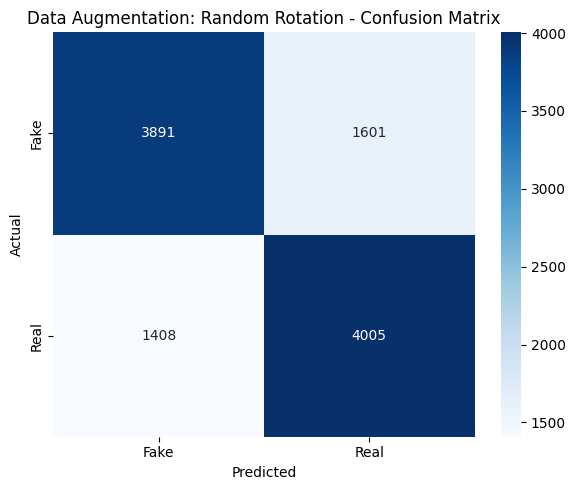

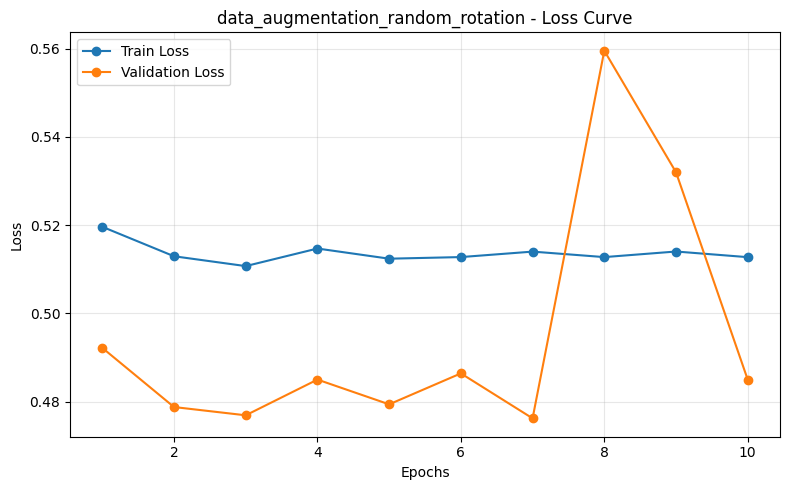

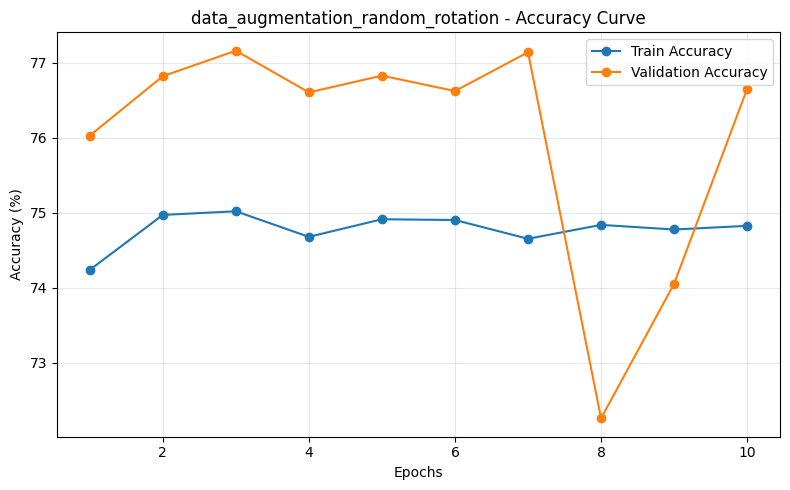

In [ ]:
# ============================================================
# METHOD 1 - DATA AUGMENTATION: RANDOM ROTATION
# This experiment tests the effect of adding RandomRotation to the
# training pipeline while keeping the rest of the setup unchanged.
# The model is trained from the same baseline architecture and the
# best weights are saved based on validation performance.
# ============================================================

block1_aug_plot_dir = "augmentation_plots"
os.makedirs(block1_aug_plot_dir, exist_ok=True)

transform_train_aug_1 = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

train_loader_aug_1, val_loader_aug_1, test_loader_aug_1 = make_loaders(transform_train_aug_1)

model_aug_1 = build_resnet50_model()
optimizer_aug_1 = torch.optim.Adam(model_aug_1.fc.parameters(), lr=0.001, weight_decay=1e-4)

results_aug_1 = run_experiment(
    exp_name="Data Augmentation: Random Rotation",
    model=model_aug_1,
    train_loader_local=train_loader_aug_1,
    val_loader_local=val_loader_aug_1,
    test_loader_local=test_loader_aug_1,
    optimizer=optimizer_aug_1,
    plot_dir=block1_aug_plot_dir,
    save_best_path="best_rotation.pth"
)

###**Data Augmentation**
Color Jitter


Data Augmentation: Color Jitter


100%|██████████| 4376/4376 [18:29<00:00,  3.94it/s]


Epoch 1/10 | Train Loss=0.4994, Train Acc=75.69% | Val Loss=0.4291, Val Acc=80.00%
  -> Best weights saved: best_colorjitter.pth


100%|██████████| 4376/4376 [17:05<00:00,  4.27it/s]


Epoch 2/10 | Train Loss=0.4932, Train Acc=76.36% | Val Loss=0.4280, Val Acc=80.38%
  -> Best weights saved: best_colorjitter.pth


...

Epoch 8/10 | Train Loss=0.4952, Train Acc=76.26% | Val Loss=0.4289, Val Acc=80.19%


100%|██████████| 4376/4376 [17:09<00:00,  4.25it/s]


Epoch 9/10 | Train Loss=0.4923, Train Acc=76.35% | Val Loss=0.4333, Val Acc=80.02%


100%|██████████| 4376/4376 [16:57<00:00,  4.30it/s]


Epoch 10/10 | Train Loss=0.4933, Train Acc=76.35% | Val Loss=0.4505, Val Acc=78.61%

Final Test Results:
------------------------------------------------------------
Best Epoch    : 2
Test Loss     : 0.5578
Test Accuracy : 71.87%
Precision     : 0.7481
Recall        : 0.6531
F1-Score      : 0.6974
Confusion Matrix:
 [[4302 1190]
 [1878 3535]]
------------------------------------------------------------


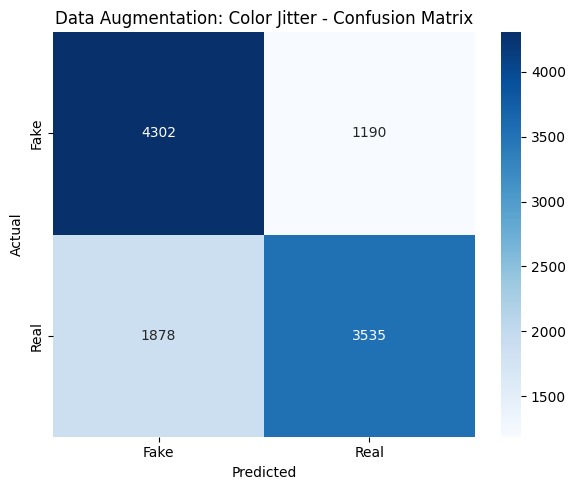

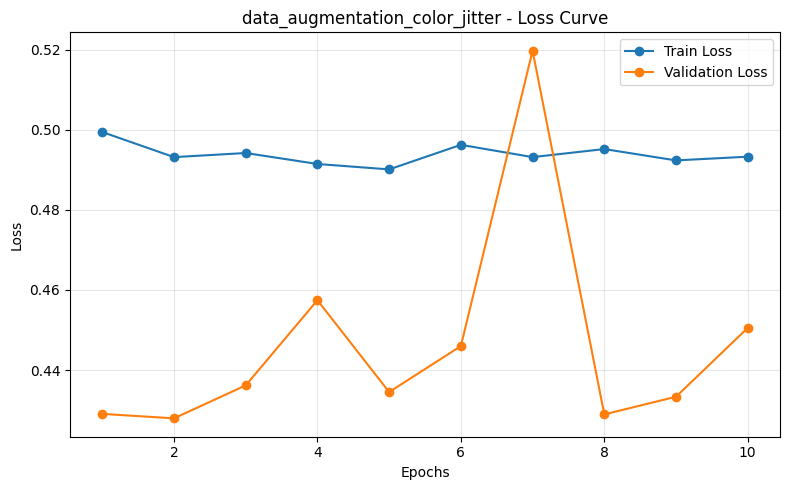

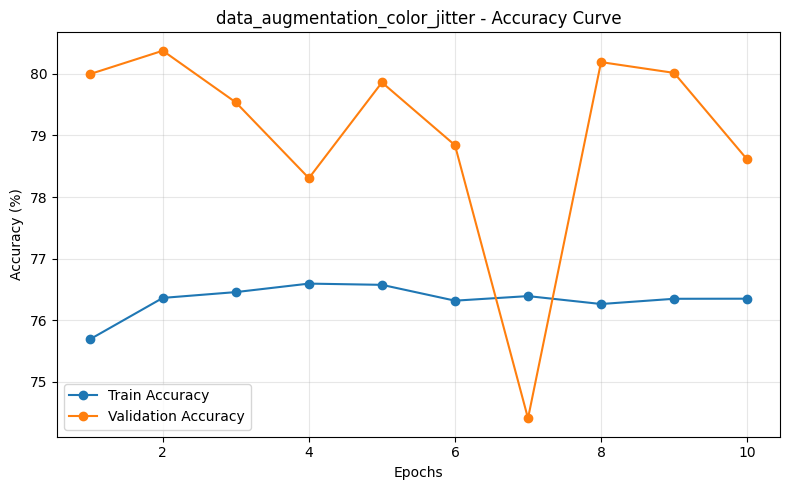

In [ ]:
# ============================================================
# METHOD 2 - DATA AUGMENTATION: COLOR JITTER
# This experiment tests the effect of adding ColorJitter to the
# training pipeline while keeping all other settings identical to
# the baseline. The goal is to isolate the effect of this single
# augmentation technique.
# ============================================================
block1_aug_plot_dir = "augmentation_plots"
transform_train_aug_2 = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

train_loader_aug_2, val_loader_aug_2, test_loader_aug_2 = make_loaders(transform_train_aug_2)

model_aug_2 = build_resnet50_model()
optimizer_aug_2 = torch.optim.Adam(model_aug_2.fc.parameters(), lr=0.001, weight_decay=1e-4)

results_aug_2 = run_experiment(
    exp_name="Data Augmentation: Color Jitter",
    model=model_aug_2,
    train_loader_local=train_loader_aug_2,
    val_loader_local=val_loader_aug_2,
    test_loader_local=test_loader_aug_2,
    optimizer=optimizer_aug_2,
    plot_dir=block1_aug_plot_dir,
    save_best_path="best_colorjitter.pth"
)

###**Comparison: Baseline vs Improvements**

Comparison: Baseline vs Random Rotation vs Color Jitter
Metric                Baseline          Random Rotation     Color Jitter      
-------------------------------------------------------------------------------------
Test Loss             0.6078            0.5468              0.5578            
Test Accuracy (%)     69.12             72.41               71.87             
Precision             0.7946            0.7144              0.7481            
Recall                0.5095            0.7399              0.6531            
F1-Score              0.6209            0.7269              0.6974            


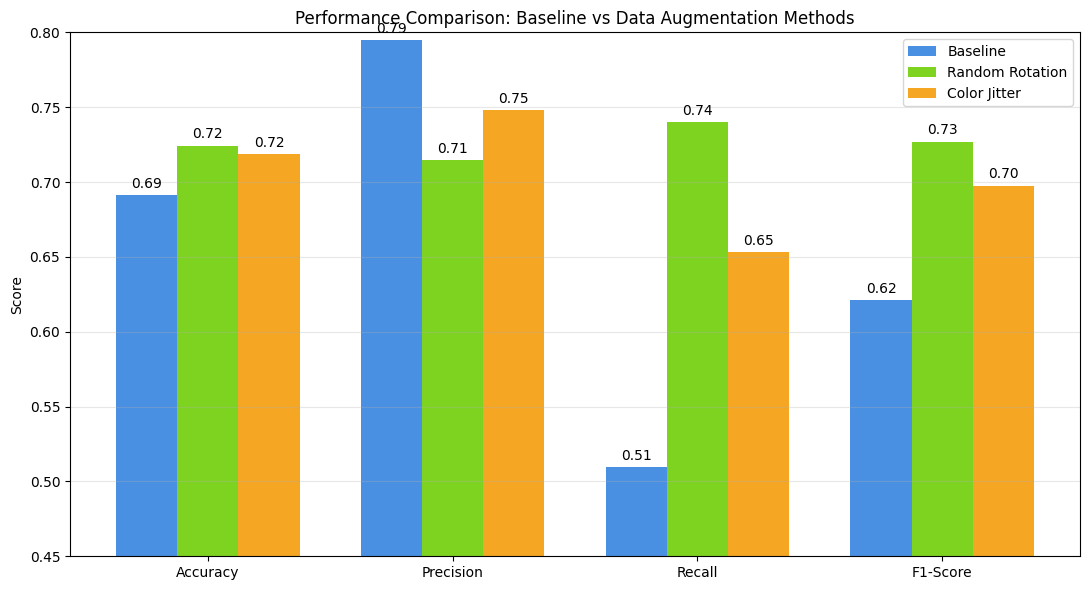

In [ ]:
# ============================================
# Comprehensive Comparison: Baseline vs Improvements
# ============================================

# Method results
rotation_test_loss     = rotation_result["test_loss"]
rotation_test_accuracy = rotation_result["test_accuracy"]
rotation_precision     = rotation_result["precision"]
rotation_recall        = rotation_result["recall"]
rotation_f1            = rotation_result["f1"]

color_test_loss     = colorjitter_result["test_loss"]
color_test_accuracy = colorjitter_result["test_accuracy"]
color_precision     = colorjitter_result["precision"]
color_recall        = colorjitter_result["recall"]
color_f1            = colorjitter_result["f1"]

# Comparison table
print("="*85)
print("Comparison: Baseline vs Improvements")
print("="*85)
print(f"{'Metric':<22}{'Baseline':<18}{'Random Rotation':<20}{'Color Jitter':<18}")
print("-"*85)
print(f"{'Test Loss':<22}{baseline_test_loss:<18.4f}{rotation_test_loss:<20.4f}{color_test_loss:<18.4f}")
print(f"{'Test Accuracy (%)':<22}{baseline_test_accuracy:<18.2f}{rotation_test_accuracy:<20.2f}{color_test_accuracy:<18.2f}")
print(f"{'Precision':<22}{baseline_precision:<18.4f}{rotation_precision:<20.4f}{color_precision:<18.4f}")
print(f"{'Recall':<22}{baseline_recall:<18.4f}{rotation_recall:<20.4f}{color_recall:<18.4f}")
print(f"{'F1-Score':<22}{baseline_f1:<18.4f}{rotation_f1:<20.4f}{color_f1:<18.4f}")
print("="*85)

# Bar chart comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
baseline_vals = [baseline_test_accuracy/100, baseline_precision, baseline_recall, baseline_f1]
rotation_vals = [rotation_test_accuracy/100, rotation_precision, rotation_recall, rotation_f1]
color_vals    = [color_test_accuracy/100, color_precision, color_recall, color_f1]

x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 6))

ax.bar(x - width, baseline_vals, width, label='Baseline', color='#4A90E2')
ax.bar(x, rotation_vals, width, label='Random Rotation', color='#7ED321')
ax.bar(x + width, color_vals, width, label='Color Jitter', color='#F5A623')

ax.set_ylabel('Score')
ax.set_title('Performance Comparison: Baseline vs Data Augmentation Methods')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([0.45, 0.80])

for i in range(len(metrics)):
    ax.text(i - width, baseline_vals[i] + 0.005, f"{baseline_vals[i]:.2f}", ha='center')
    ax.text(i, rotation_vals[i] + 0.005, f"{rotation_vals[i]:.2f}", ha='center')
    ax.text(i + width, color_vals[i] + 0.005, f"{color_vals[i]:.2f}", ha='center')

plt.tight_layout()
plt.show()

###**Optimizer**
SGD (Stochastic Gradient Descent)


Optimizer: SGD


100%|██████████| 4376/4376 [08:48<00:00,  8.28it/s]


Epoch 1/10 | Train Loss=0.7513, Train Acc=72.67% | Val Loss=0.6701, Val Acc=73.60%
  -> Best weights saved: best_sgd.pth


100%|██████████| 4376/4376 [08:44<00:00,  8.34it/s]


Epoch 2/10 | Train Loss=0.7648, Train Acc=72.71% | Val Loss=0.7783, Val Acc=71.30%


...

Epoch 8/10 | Train Loss=0.7565, Train Acc=72.70% | Val Loss=0.6544, Val Acc=73.24%


100%|██████████| 4376/4376 [08:46<00:00,  8.32it/s]


Epoch 9/10 | Train Loss=0.7585, Train Acc=72.93% | Val Loss=0.6039, Val Acc=75.89%


100%|██████████| 4376/4376 [08:41<00:00,  8.39it/s]


Epoch 10/10 | Train Loss=0.7626, Train Acc=72.95% | Val Loss=0.6195, Val Acc=75.11%

Final Test Results:
------------------------------------------------------------
Best Epoch    : 3
Test Loss     : 0.6229
Test Accuracy : 72.54%
Precision     : 0.7556
Recall        : 0.6603
F1-Score      : 0.7047
Confusion Matrix:
 [[4336 1156]
 [1839 3574]]
------------------------------------------------------------


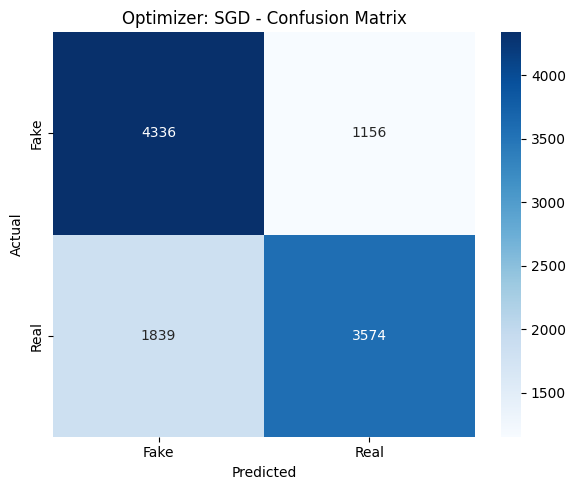

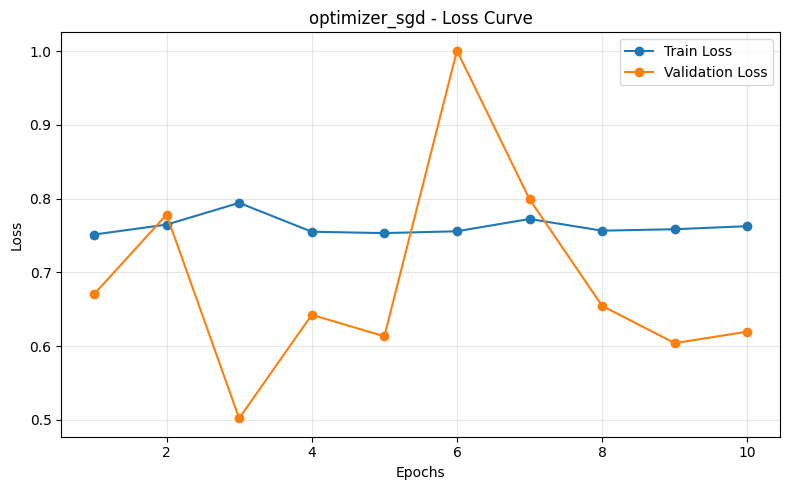

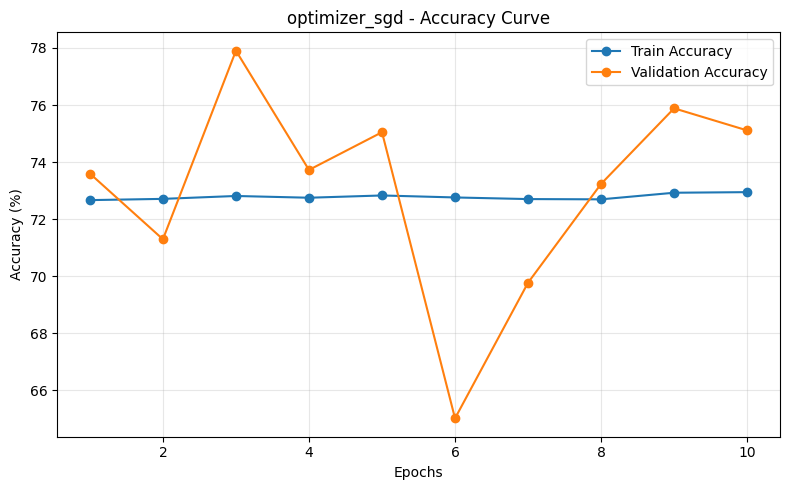

In [ ]:
# ============================================================
# METHOD 3 - OPTIMIZER: SGD
# This experiment changes only the optimizer from Adam to SGD while
# keeping the model architecture, dataset, and training settings the
# same. The best model weights are saved during training.
# ============================================================

block1_opt_plot_dir = "optimizer_plots"
os.makedirs(block1_opt_plot_dir, exist_ok=True)

model_opt_1 = build_resnet50_model()
optimizer_opt_1 = torch.optim.SGD(
    model_opt_1.fc.parameters(),
    lr=0.01,
    momentum=0.9,
    weight_decay=1e-4
)

results_opt_1 = run_experiment(
    exp_name="Optimizer: SGD",
    model=model_opt_1,
    train_loader_local=train_loader,
    val_loader_local=val_loader,
    test_loader_local=test_loader,
    optimizer=optimizer_opt_1,
    plot_dir=block1_opt_plot_dir,
    save_best_path="best_sgd.pth"
)

###**Optimizer**
RMSprop


Optimizer: RMSprop


100%|██████████| 4376/4376 [09:17<00:00,  7.85it/s]


Epoch 1/10 | Train Loss=0.8003, Train Acc=72.33% | Val Loss=0.4972, Val Acc=77.98%
  -> Best weights saved: best_rmsprop.pth


100%|██████████| 4376/4376 [08:03<00:00,  9.06it/s]


Epoch 2/10 | Train Loss=0.7896, Train Acc=72.39% | Val Loss=0.5939, Val Acc=77.02%


...

Epoch 8/10 | Train Loss=0.7688, Train Acc=72.77% | Val Loss=0.4810, Val Acc=78.84%
  -> Best weights saved: best_rmsprop.pth


100%|██████████| 4376/4376 [08:04<00:00,  9.03it/s]


Epoch 9/10 | Train Loss=0.7838, Train Acc=72.48% | Val Loss=1.4412, Val Acc=60.56%


100%|██████████| 4376/4376 [08:08<00:00,  8.96it/s]


Epoch 10/10 | Train Loss=0.7799, Train Acc=72.70% | Val Loss=0.6140, Val Acc=75.74%

Final Test Results:
------------------------------------------------------------
Best Epoch    : 8
Test Loss     : 0.6441
Test Accuracy : 71.76%
Precision     : 0.7274
Recall        : 0.6893
F1-Score      : 0.7078
Confusion Matrix:
 [[4094 1398]
 [1682 3731]]
------------------------------------------------------------


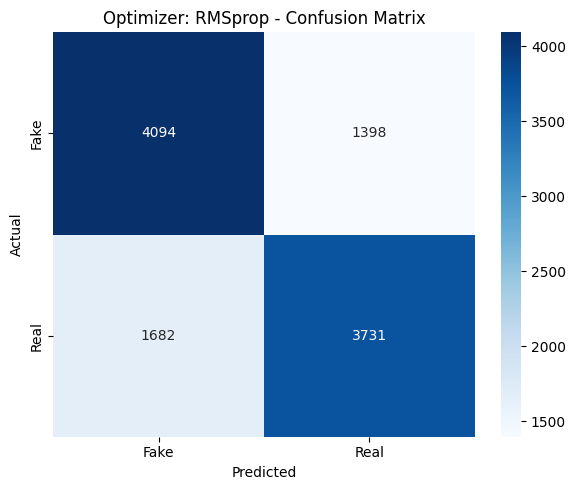

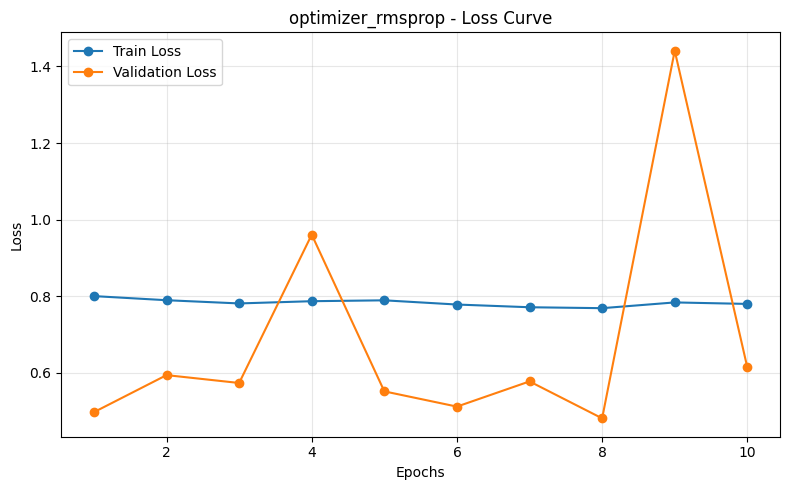

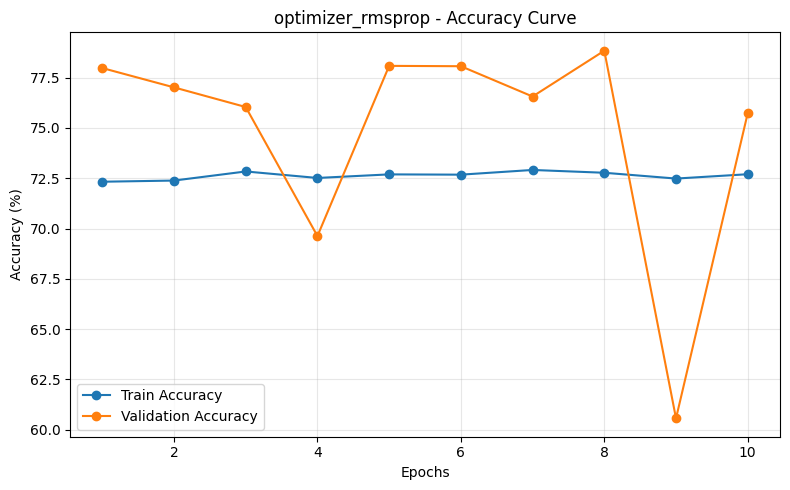

In [ ]:
# ============================================================
# METHOD 4 - OPTIMIZER: RMSprop
# This experiment changes only the optimizer to RMSprop
# while keeping the rest of the pipeline unchanged. This allows a
# fair comparison with the baseline optimizer.
# ============================================================
block1_opt_plot_dir = "optimizer_plots"
model_opt_2 = build_resnet50_model()
optimizer_opt_2 = torch.optim.RMSprop(
    model_opt_2.fc.parameters(),
    lr=0.001,
    alpha=0.99,
    momentum=0.9,
    weight_decay=1e-4
)

results_opt_2 = run_experiment(
    exp_name="Optimizer: RMSprop",
    model=model_opt_2,
    train_loader_local=train_loader,
    val_loader_local=val_loader,
    test_loader_local=test_loader,
    optimizer=optimizer_opt_2,
    plot_dir=block1_opt_plot_dir,
    save_best_path="best_rmsprop.pth"
)

###**Comparison: Baseline vs Improvements**

Comparison: Baseline vs SGD vs RMSprop
Metric                Baseline          SGD                 RMSprop           
-------------------------------------------------------------------------------------
Test Loss             0.6078            0.6229              0.6441            
Test Accuracy (%)     69.12             72.54               71.76             
Precision             0.7946            0.7556              0.7274            
Recall                0.5095            0.6603              0.6893            
F1-Score              0.6209            0.7047              0.7078            


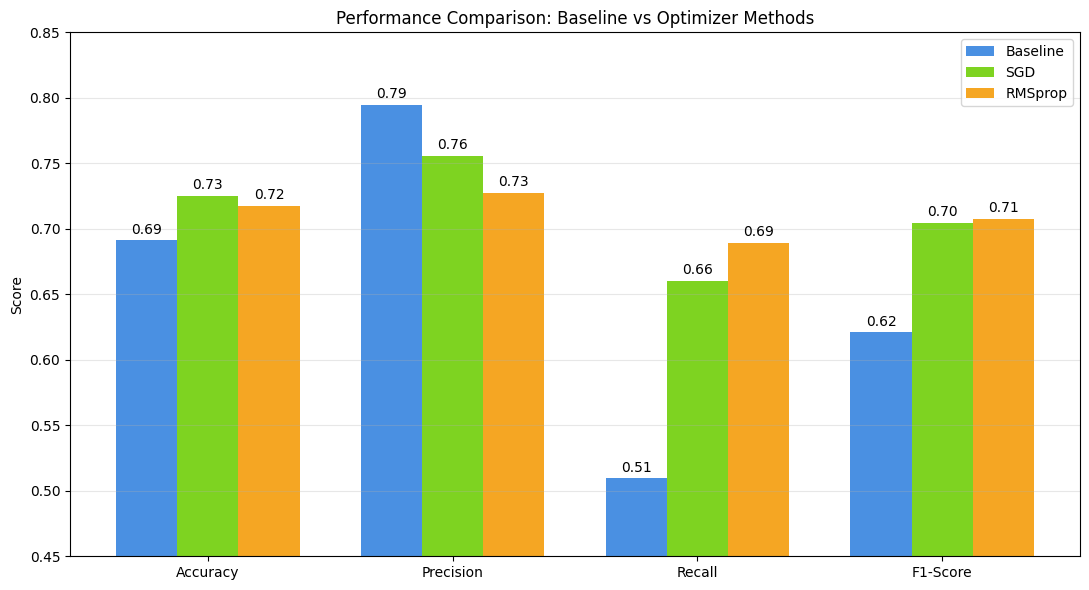

In [ ]:
# ============================================
# Comprehensive Comparison: Baseline vs Improvements
# ============================================

# Method results
sgd_test_loss     = sgd_result["test_loss"]
sgd_test_accuracy = sgd_result["test_accuracy"]
sgd_precision     = sgd_result["precision"]
sgd_recall        = sgd_result["recall"]
sgd_f1            = sgd_result["f1"]

rms_test_loss     = rmsprop_result["test_loss"]
rms_test_accuracy = rmsprop_result["test_accuracy"]
rms_precision     = rmsprop_result["precision"]
rms_recall        = rmsprop_result["recall"]
rms_f1            = rmsprop_result["f1"]

# Comparison table
print("="*85)
print("Comparison: Baseline vs Improvements")
print("="*85)
print(f"{'Metric':<22}{'Baseline':<18}{'SGD':<20}{'RMSprop':<18}")
print("-"*85)
print(f"{'Test Loss':<22}{baseline_test_loss:<18.4f}{sgd_test_loss:<20.4f}{rms_test_loss:<18.4f}")
print(f"{'Test Accuracy (%)':<22}{baseline_test_accuracy:<18.2f}{sgd_test_accuracy:<20.2f}{rms_test_accuracy:<18.2f}")
print(f"{'Precision':<22}{baseline_precision:<18.4f}{sgd_precision:<20.4f}{rms_precision:<18.4f}")
print(f"{'Recall':<22}{baseline_recall:<18.4f}{sgd_recall:<20.4f}{rms_recall:<18.4f}")
print(f"{'F1-Score':<22}{baseline_f1:<18.4f}{sgd_f1:<20.4f}{rms_f1:<18.4f}")
print("="*85)

# Bar chart comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
baseline_vals = [baseline_test_accuracy/100, baseline_precision, baseline_recall, baseline_f1]
sgd_vals      = [sgd_test_accuracy/100, sgd_precision, sgd_recall, sgd_f1]
rms_vals      = [rms_test_accuracy/100, rms_precision, rms_recall, rms_f1]

x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 6))

ax.bar(x - width, baseline_vals, width, label='Baseline', color='#4A90E2')
ax.bar(x, sgd_vals, width, label='SGD', color='#7ED321')
ax.bar(x + width, rms_vals, width, label='RMSprop', color='#F5A623')

ax.set_ylabel('Score')
ax.set_title('Performance Comparison: Baseline vs Optimizer Methods')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([0.45, 0.85])

for i in range(len(metrics)):
    ax.text(i - width, baseline_vals[i] + 0.005, f"{baseline_vals[i]:.2f}", ha='center')
    ax.text(i, sgd_vals[i] + 0.005, f"{sgd_vals[i]:.2f}", ha='center')
    ax.text(i + width, rms_vals[i] + 0.005, f"{rms_vals[i]:.2f}", ha='center')

plt.tight_layout()
plt.show()

##Basmah Mohammed | 445013838

###**FC Layer + Number of Neurons Common Setup**

In [ ]:
# ============================================================
# FC Layer + Number of Neurons Common Setup
# This section imports the required libraries, defines the device,
# sets the training parameters, stores the baseline metrics,
# and creates the helper functions used in the FC experiments.
# ============================================================

import os
import copy
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torchvision.models as models
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

# Use GPU if available; otherwise use CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Binary classification loss function
criterion = nn.BCEWithLogitsLoss()

# Number of epochs used for both FC experiments
EPOCHS = 10

# Baseline performance values used for comparison
baseline_test_loss     = 0.6078
baseline_test_accuracy = 69.12
baseline_precision     = 0.7946
baseline_recall        = 0.5095
baseline_f1            = 0.6209

# Store baseline metrics in one dictionary for easy plotting/comparison
baseline_metrics = {
    "loss": baseline_test_loss,
    "accuracy": baseline_test_accuracy,
    "precision": baseline_precision,
    "recall": baseline_recall,
    "f1": baseline_f1
}

# Convert experiment names into safe file names for saving plots
def slugify(text):
    return (
        text.lower()
        .replace(" ", "_")
        .replace(":", "")
        .replace("+", "plus")
        .replace("/", "_")
    )

# Build the ResNet50 model with a customizable fully connected head
# This function is used to test different numbers of neurons in the FC layer
def build_resnet50_model(hidden_neurons=None):
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

    # Freeze the pretrained backbone so only the FC head is trained
    for param in model.parameters():
        param.requires_grad = False

    # Get the number of features from the original FC layer
    num_features = model.fc.in_features

    # Build the new FC head depending on the selected number of neurons
    if hidden_neurons == 512:
        model.fc = nn.Sequential(
            nn.Linear(num_features, 512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, 1)
        )
    elif hidden_neurons == 128:
        model.fc = nn.Sequential(
            nn.Linear(num_features, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1)
        )
    else:
        raise ValueError("hidden_neurons must be 512 or 128 for this block")

    return model.to(device)

# Plot and save the confusion matrix for each FC experiment
def plot_confusion_matrix(cm, title, save_path=None):
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Fake", "Real"],
        yticklabels=["Fake", "Real"]
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

# Plot and save training/validation loss and accuracy curves
def plot_curves(train_losses, val_losses, train_accs, val_accs, title_prefix, save_dir=None):
    # Loss curve
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, len(train_losses) + 1), train_losses, marker='o', label="Train Loss")
    plt.plot(range(1, len(val_losses) + 1), val_losses, marker='o', label="Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title(f"{title_prefix} - Loss Curve")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    if save_dir:
        plt.savefig(os.path.join(save_dir, f"{title_prefix}_loss.png"), dpi=300, bbox_inches="tight")
    plt.show()

    # Accuracy curve
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, len(train_accs) + 1), train_accs, marker='o', label="Train Accuracy")
    plt.plot(range(1, len(val_accs) + 1), val_accs, marker='o', label="Validation Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy (%)")
    plt.title(f"{title_prefix} - Accuracy Curve")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    if save_dir:
        plt.savefig(os.path.join(save_dir, f"{title_prefix}_accuracy.png"), dpi=300, bbox_inches="tight")
    plt.show()

# Compare two FC experiments with the baseline in a bar chart
def plot_comparison_with_baseline(title, labels, baseline_metrics, results_list, save_path=None):
    metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]

    # Convert the stored results into values ready for plotting
    values = [
        [baseline_metrics["accuracy"] / 100.0, baseline_metrics["precision"], baseline_metrics["recall"], baseline_metrics["f1"]],
        [results_list[0]["test_accuracy"] / 100.0, results_list[0]["precision"], results_list[0]["recall"], results_list[0]["f1"]],
        [results_list[1]["test_accuracy"] / 100.0, results_list[1]["precision"], results_list[1]["recall"], results_list[1]["f1"]],
    ]

    x = np.arange(len(metrics))
    width = 0.25

    plt.figure(figsize=(11, 6))
    plt.bar(x - width, values[0], width, label="Baseline")
    plt.bar(x,         values[1], width, label=labels[0])
    plt.bar(x + width, values[2], width, label=labels[1])

    plt.ylabel("Score")
    plt.title(title)
    plt.xticks(x, metrics)
    plt.ylim(0.0, 1.0)
    plt.grid(True, alpha=0.3, axis='y')
    plt.legend()
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

# Train the model, save the best weights, evaluate on the test set,
# and return all results for later comparison
def run_experiment(
    exp_name,
    model,
    train_loader_local,
    val_loader_local,
    test_loader_local,
    optimizer,
    plot_dir,
    save_best_path
):
    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []

    # Track the best validation accuracy and keep the corresponding model state
    best_val_acc = -1.0
    best_val_loss = float("inf")
    best_state = copy.deepcopy(model.state_dict())
    best_epoch = 0

    print("\n" + "=" * 90)
    print(exp_name)
    print("=" * 90)

    # Training loop
    for epoch in range(EPOCHS):
        train_loss, train_acc = train_one_epoch(
            model, train_loader_local, criterion, optimizer, device
        )
        val_loss, val_acc = validate(
            model, val_loader_local, criterion, device
        )

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        print(
            f"Epoch {epoch+1}/{EPOCHS} | "
            f"Train Loss={train_loss:.4f}, Train Acc={train_acc:.2f}% | "
            f"Val Loss={val_loss:.4f}, Val Acc={val_acc:.2f}%"
        )

        # Save the best weights based on validation accuracy
        if (val_acc > best_val_acc) or (val_acc == best_val_acc and val_loss < best_val_loss):
            best_val_acc = val_acc
            best_val_loss = val_loss
            best_epoch = epoch + 1
            best_state = copy.deepcopy(model.state_dict())
            torch.save(best_state, save_best_path)
            print(f"  -> Best weights saved: {save_best_path}")

    # Restore the best model before final test evaluation
    model.load_state_dict(best_state)

    # Final evaluation on the test set
    test_loss, test_accuracy, precision, recall, f1, cm = evaluate(
        model, test_loader_local, criterion, device
    )

    print("\nFinal Test Results:")
    print("-" * 60)
    print(f"Best Epoch    : {best_epoch}")
    print(f"Test Loss     : {test_loss:.4f}")
    print(f"Test Accuracy : {test_accuracy:.2f}%")
    print(f"Precision     : {precision:.4f}")
    print(f"Recall        : {recall:.4f}")
    print(f"F1-Score      : {f1:.4f}")
    print("Confusion Matrix:\n", cm)
    print("-" * 60)

    # Save plots for this FC experiment
    os.makedirs(plot_dir, exist_ok=True)
    safe_name = slugify(exp_name)

    plot_confusion_matrix(
        cm,
        title=exp_name + " - Confusion Matrix",
        save_path=os.path.join(plot_dir, f"{safe_name}_cm.png")
    )
    plot_curves(
        train_losses, val_losses, train_accs, val_accs,
        title_prefix=safe_name,
        save_dir=plot_dir
    )

    # Return all metrics and history for later comparison
    return {
        "exp_name": exp_name,
        "best_epoch": best_epoch,
        "best_val_acc": best_val_acc,
        "best_val_loss": best_val_loss,
        "test_loss": test_loss,
        "test_accuracy": test_accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "cm": cm,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "train_accs": train_accs,
        "val_accs": val_accs,
        "best_state_dict_path": save_best_path
    }

###**FC Layer with 512 Neurons**


FC Layer: 512 Neurons


100%|██████████| 4376/4376 [09:28<00:00,  7.70it/s]


Epoch 1/10 | Train Loss=0.4299, Train Acc=79.87% | Val Loss=0.4529, Val Acc=78.64%
  -> Best weights saved: best_fc512.pth


100%|██████████| 4376/4376 [09:02<00:00,  8.07it/s]


Epoch 2/10 | Train Loss=0.3973, Train Acc=81.63% | Val Loss=0.4246, Val Acc=79.95%
  -> Best weights saved: best_fc512.pth


...

Epoch 8/10 | Train Loss=0.3737, Train Acc=83.11% | Val Loss=0.4036, Val Acc=81.00%


100%|██████████| 4376/4376 [09:00<00:00,  8.09it/s]


Epoch 9/10 | Train Loss=0.3732, Train Acc=83.21% | Val Loss=0.3866, Val Acc=82.25%


100%|██████████| 4376/4376 [08:59<00:00,  8.12it/s]


Epoch 10/10 | Train Loss=0.3706, Train Acc=83.40% | Val Loss=0.3797, Val Acc=82.83%
  -> Best weights saved: best_fc512.pth

Final Test Results:
------------------------------------------------------------
Best Epoch    : 10
Test Loss     : 0.5899
Test Accuracy : 71.36%
Precision     : 0.7999
Recall        : 0.5642
F1-Score      : 0.6617
Confusion Matrix:
 [[4728  764]
 [2359 3054]]
------------------------------------------------------------


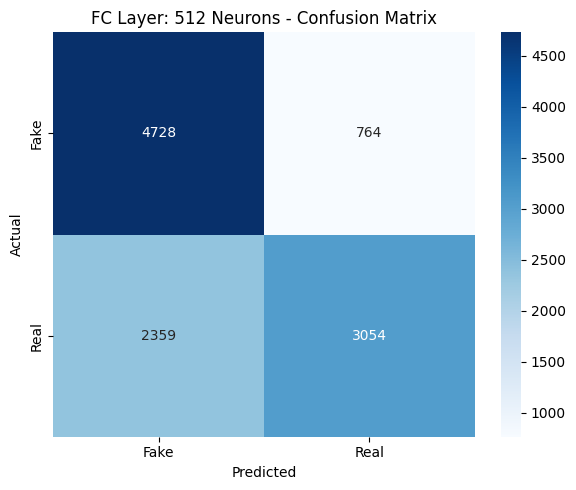

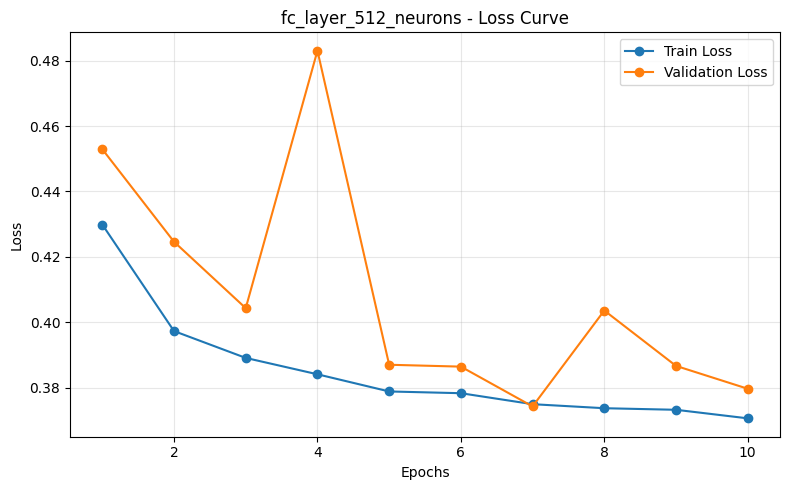

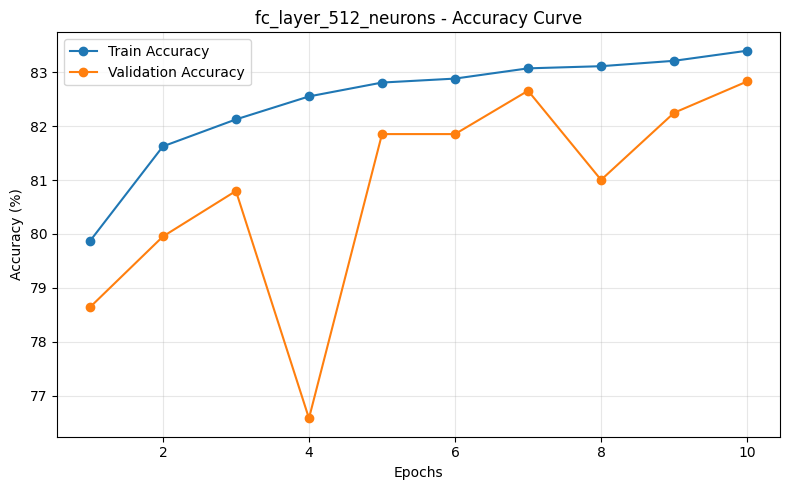

In [ ]:
# ============================================================
# METHOD 1 - FC LAYER WITH 512 NEURONS
# This experiment tests a larger fully connected head by adding
# a hidden layer with 512 neurons. The goal is to check whether
# increasing the number of neurons improves classification.
# ============================================================

block2_plot_dir = "fc_plots"
os.makedirs(block2_plot_dir, exist_ok=True)

model_fc_512 = build_resnet50_model(hidden_neurons=512)

# Use Adam optimizer for the first FC experiment
optimizer_fc_512 = torch.optim.Adam(
    model_fc_512.fc.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

# Train the 512-neuron FC model and save the best weights
results_fc_512 = run_experiment(
    exp_name="FC Layer: 512 Neurons",
    model=model_fc_512,
    train_loader_local=train_loader,
    val_loader_local=val_loader,
    test_loader_local=test_loader,
    optimizer=optimizer_fc_512,
    plot_dir=block2_plot_dir,
    save_best_path="best_fc512.pth"
)

###**FC Layer with 128 Neurons**


FC Layer: 128 Neurons


100%|██████████| 4376/4376 [09:47<00:00,  7.44it/s]


Epoch 1/10 | Train Loss=0.4217, Train Acc=80.42% | Val Loss=0.4346, Val Acc=78.57%
  -> Best weights saved: best_fc128.pth


100%|██████████| 4376/4376 [09:33<00:00,  7.64it/s]


Epoch 2/10 | Train Loss=0.3921, Train Acc=82.02% | Val Loss=0.4088, Val Acc=81.03%
  -> Best weights saved: best_fc128.pth


...

Epoch 8/10 | Train Loss=0.3611, Train Acc=83.76% | Val Loss=0.3610, Val Acc=83.83%
  -> Best weights saved: best_fc128.pth


100%|██████████| 4376/4376 [09:29<00:00,  7.68it/s]


Epoch 9/10 | Train Loss=0.3581, Train Acc=84.01% | Val Loss=0.3644, Val Acc=83.35%


100%|██████████| 4376/4376 [09:31<00:00,  7.66it/s]


Epoch 10/10 | Train Loss=0.3576, Train Acc=84.03% | Val Loss=0.3653, Val Acc=83.51%

Final Test Results:
------------------------------------------------------------
Best Epoch    : 8
Test Loss     : 0.6342
Test Accuracy : 70.78%
Precision     : 0.7950
Recall        : 0.5544
F1-Score      : 0.6532
Confusion Matrix:
 [[4718  774]
 [2412 3001]]
------------------------------------------------------------


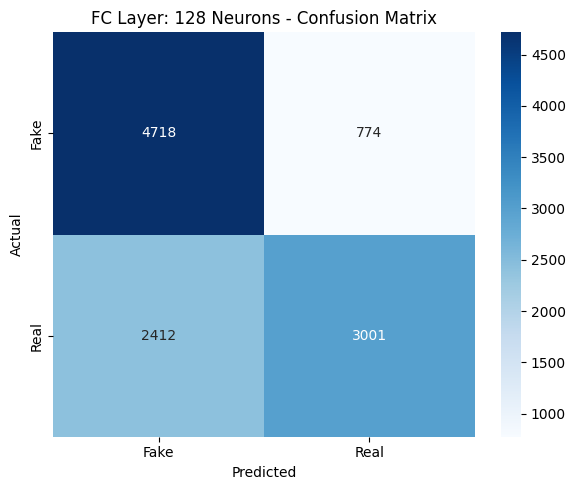

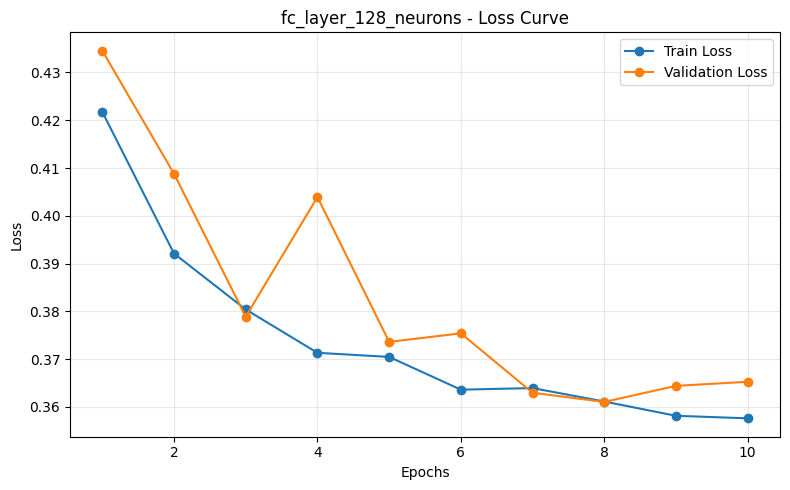

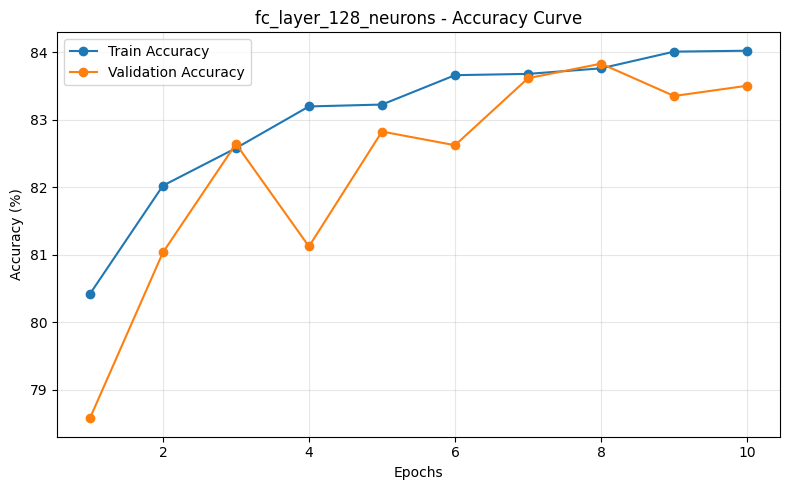

In [ ]:

# ============================================================
# METHOD 2 - FC LAYER WITH 128 NEURONS
# This experiment tests a smaller fully connected head by using
# a hidden layer with 128 neurons. The purpose is to compare the
# effect of reducing the number of neurons on model performance.
# ============================================================

model_fc_128 = build_resnet50_model(hidden_neurons=128)
block2_plot_dir = "fc_plots"
# Use the same optimizer setup for a fair comparison
optimizer_fc_128 = torch.optim.Adam(
    model_fc_128.fc.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

# Train the 128-neuron FC model and save the best weights
results_fc_128 = run_experiment(
    exp_name="FC Layer: 128 Neurons",
    model=model_fc_128,
    train_loader_local=train_loader,
    val_loader_local=val_loader,
    test_loader_local=test_loader,
    optimizer=optimizer_fc_128,
    plot_dir=block2_plot_dir,
    save_best_path="best_fc128.pth"
)

###**Comparison: Baseline vs Improvements**

Comparison: Baseline vs FC512 vs FC128
Metric                Baseline          FC512               FC128             
-------------------------------------------------------------------------------------
Test Loss             0.6078            0.5899              0.6342            
Test Accuracy (%)     69.12             71.36               70.78             
Precision             0.7946            0.7999              0.7950            
Recall                0.5095            0.5642              0.5544            
F1-Score              0.6209            0.6617              0.6532            


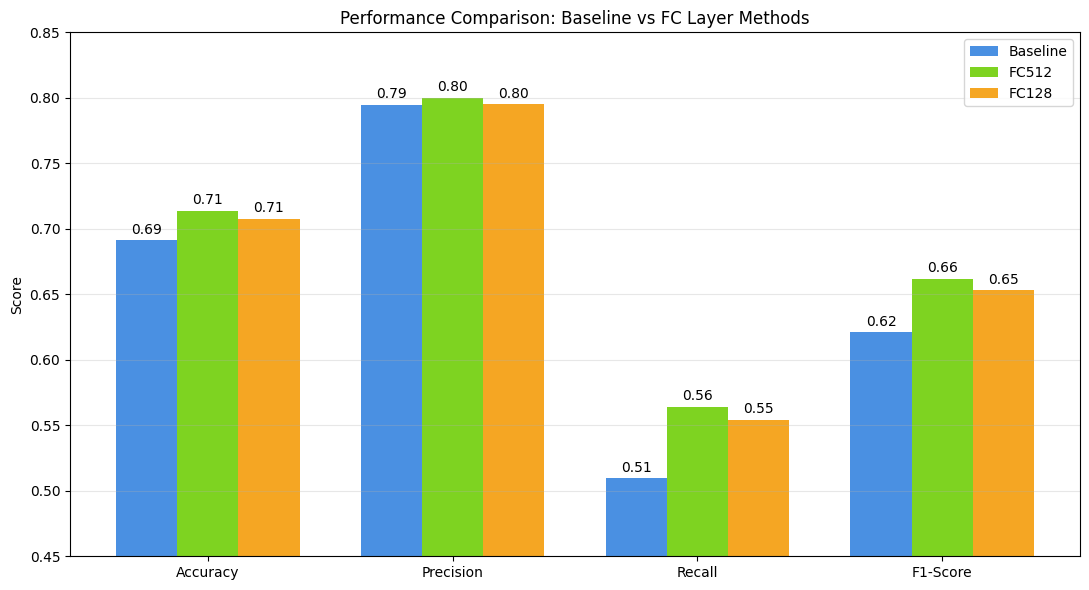

In [ ]:
# ============================================
# Comprehensive Comparison: Baseline vs Improvements
# ============================================

# Method results
fc512_test_loss     = fc512_result["test_loss"]
fc512_test_accuracy = fc512_result["test_accuracy"]
fc512_precision     = fc512_result["precision"]
fc512_recall        = fc512_result["recall"]
fc512_f1            = fc512_result["f1"]

fc128_test_loss     = fc128_result["test_loss"]
fc128_test_accuracy = fc128_result["test_accuracy"]
fc128_precision     = fc128_result["precision"]
fc128_recall        = fc128_result["recall"]
fc128_f1            = fc128_result["f1"]

# Comparison table
print("="*85)
print("Comparison: Baseline vs Improvements")
print("="*85)
print(f"{'Metric':<22}{'Baseline':<18}{'FC512':<20}{'FC128':<18}")
print("-"*85)
print(f"{'Test Loss':<22}{baseline_test_loss:<18.4f}{fc512_test_loss:<20.4f}{fc128_test_loss:<18.4f}")
print(f"{'Test Accuracy (%)':<22}{baseline_test_accuracy:<18.2f}{fc512_test_accuracy:<20.2f}{fc128_test_accuracy:<18.2f}")
print(f"{'Precision':<22}{baseline_precision:<18.4f}{fc512_precision:<20.4f}{fc128_precision:<18.4f}")
print(f"{'Recall':<22}{baseline_recall:<18.4f}{fc512_recall:<20.4f}{fc128_recall:<18.4f}")
print(f"{'F1-Score':<22}{baseline_f1:<18.4f}{fc512_f1:<20.4f}{fc128_f1:<18.4f}")
print("="*85)

# Bar chart comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
baseline_vals = [baseline_test_accuracy/100, baseline_precision, baseline_recall, baseline_f1]
fc512_vals    = [fc512_test_accuracy/100, fc512_precision, fc512_recall, fc512_f1]
fc128_vals    = [fc128_test_accuracy/100, fc128_precision, fc128_recall, fc128_f1]

x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 6))

ax.bar(x - width, baseline_vals, width, label='Baseline', color='#4A90E2')
ax.bar(x, fc512_vals, width, label='FC512', color='#7ED321')
ax.bar(x + width, fc128_vals, width, label='FC128', color='#F5A623')

ax.set_ylabel('Score')
ax.set_title('Performance Comparison: Baseline vs FC Layer Methods')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([0.45, 0.85])

for i in range(len(metrics)):
    ax.text(i - width, baseline_vals[i] + 0.005, f"{baseline_vals[i]:.2f}", ha='center')
    ax.text(i, fc512_vals[i] + 0.005, f"{fc512_vals[i]:.2f}", ha='center')
    ax.text(i + width, fc128_vals[i] + 0.005, f"{fc128_vals[i]:.2f}", ha='center')

plt.tight_layout()
plt.show()

##Jenan Bajawi | 445000496

###**Learning Rate Scheduler (ReduceLROnPlateau)**

In [ ]:
# ============================================================
# Improvement 1: Learning Rate Scheduler (ReduceLROnPlateau)
# ============================================================
#
# Reference:
# - Smith, L. N. (2017). "Cyclical Learning Rates for Training
#   Neural Networks." IEEE Winter Conference on Applications of
#   Computer Vision (WACV).
# - PyTorch Documentation: ReduceLROnPlateau
#   https://pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.ReduceLROnPlateau.html
#
# Methodology:
# This experiment introduces ONLY a learning rate scheduler to the
# baseline configuration. All other hyperparameters (architecture,
# optimizer, batch size, epochs, dropout) remain identical to the
# baseline to ensure a fair comparison and isolate the scheduler's
# effect on model performance.
# ============================================================

import copy
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Use the same device as baseline
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- Build model (IDENTICAL to baseline) ---
model_lr = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

# Freeze all backbone layers (transfer learning, same as baseline)
for param in model_lr.parameters():
    param.requires_grad = False

# Replace final FC layer (same as baseline)
num_features = model_lr.fc.in_features
model_lr.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(num_features, 1)
)
model_lr = model_lr.to(device)

# --- Loss and Optimizer (IDENTICAL to baseline) ---
criterion_lr = nn.BCEWithLogitsLoss()
optimizer_lr = torch.optim.Adam(
    model_lr.fc.parameters(),
    lr=0.001,           # Same as baseline
    weight_decay=1e-4   # Same as baseline
)

# --- IMPROVEMENT: Learning Rate Scheduler ---
#
# Standard parameters from PyTorch documentation:
# - mode='min'    : monitor metric to be minimized (val_loss)
# - factor=0.5    : reduce lr by half when triggered (standard value)
# - patience=2    : wait 2 epochs without improvement before reducing
# - min_lr=1e-6   : prevent lr from becoming too small
#
# These are conservative, widely-used defaults documented in:
# https://pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.ReduceLROnPlateau.html
scheduler_lr = ReduceLROnPlateau(
    optimizer_lr,
    mode='min',
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

# --- Training (10 epochs, SAME as baseline) ---
num_epochs = 10

lr_train_losses = []
lr_val_losses = []
lr_train_accuracies = []
lr_val_accuracies = []
learning_rates = []

print("="*60)
print("Improvement 1: Learning Rate Scheduler")
print("="*60)

for epoch in range(num_epochs):
    # Train for one epoch
    train_loss, train_accuracy = train_one_epoch(
        model_lr, train_loader, criterion_lr, optimizer_lr, device
    )

    # Validate
    val_loss, val_accuracy = validate(
        model_lr, val_loader, criterion_lr, device
    )

    # Save metrics
    lr_train_losses.append(train_loss)
    lr_val_losses.append(val_loss)
    lr_train_accuracies.append(train_accuracy)
    lr_val_accuracies.append(val_accuracy)

    # Track learning rate (to show scheduler effect)
    current_lr = optimizer_lr.param_groups[0]['lr']
    learning_rates.append(current_lr)

    # Print progress
    print(f"Epoch {epoch+1}/{num_epochs}: "
          f"Train Loss={train_loss:.4f}, Train Acc={train_accuracy:.2f}%, "
          f"Val Loss={val_loss:.4f}, Val Acc={val_accuracy:.2f}%, "
          f"LR={current_lr:.6f}")

    # Apply scheduler based on validation loss
    scheduler_lr.step(val_loss)

# --- Final evaluation on test set ---
lr_test_loss, lr_test_accuracy, lr_precision, lr_recall, lr_f1, lr_cm = evaluate(
    model_lr, test_loader, criterion_lr, device
)

# Print final results
print("\nLR Scheduler - Final Test Results:")
print("-"*40)
print(f"Test Loss     : {lr_test_loss:.4f}")
print(f"Test Accuracy : {lr_test_accuracy:.2f}%")
print(f"Precision     : {lr_precision:.4f}")
print(f"Recall        : {lr_recall:.4f}")
print(f"F1-Score      : {lr_f1:.4f}")
print("-"*40)
print("Confusion Matrix:\n", lr_cm)

# Save the model
torch.save(model_lr.state_dict(), "lr_scheduler_model.pth")
print("\nModel saved as: lr_scheduler_model.pth")

Improvement 1: Learning Rate Scheduler


100%|██████████| 4376/4376 [04:24<00:00, 16.56it/s]


Epoch 1/10: Train Loss=0.4855, Train Acc=76.63%, Val Loss=0.4329, Val Acc=79.75%, LR=0.001000


100%|██████████| 4376/4376 [03:29<00:00, 20.86it/s]


Epoch 2/10: Train Loss=0.4758, Train Acc=77.62%, Val Loss=0.4187, Val Acc=80.46%, LR=0.001000


...

Epoch 8/10: Train Loss=0.4660, Train Acc=77.92%, Val Loss=0.4313, Val Acc=79.93%, LR=0.000500


100%|██████████| 4376/4376 [03:29<00:00, 20.87it/s]


Epoch 9/10: Train Loss=0.4583, Train Acc=78.47%, Val Loss=0.4286, Val Acc=79.97%, LR=0.000250


100%|██████████| 4376/4376 [03:30<00:00, 20.83it/s]


Epoch 10/10: Train Loss=0.4563, Train Acc=78.43%, Val Loss=0.4197, Val Acc=80.65%, LR=0.000250

LR Scheduler - Final Test Results:
----------------------------------------
Test Loss     : 0.5511
Test Accuracy : 72.05%
Precision     : 0.7611
Recall        : 0.6368
F1-Score      : 0.6934
----------------------------------------
Confusion Matrix:
 [[4410 1082]
 [1966 3447]]

Model saved as: lr_scheduler_model.pth


###**Early Stopping**

In [ ]:
# ============================================================
# Improvement 2: Early Stopping
# ============================================================
#
# Reference:
# - Prechelt, L. (1998). "Early Stopping - But When?"
#   in Neural Networks: Tricks of the Trade. Springer, pp. 55-69.
# - Goodfellow, I., Bengio, Y., & Courville, A. (2016).
#   Deep Learning. MIT Press, Chapter 7.8.
#
# Methodology:
# This experiment introduces ONLY Early Stopping to the baseline
# configuration. All other hyperparameters remain identical to the
# baseline. Early Stopping monitors the validation loss and
# automatically halts training when no improvement is observed
# for a specified number of epochs (patience), preventing
# overfitting and reducing computational cost.
# ============================================================

# --- Build model (IDENTICAL to baseline) ---
model_es = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

# Freeze all backbone layers (same as baseline)
for param in model_es.parameters():
    param.requires_grad = False

# Replace final FC layer (same as baseline)
model_es.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(num_features, 1)
)
model_es = model_es.to(device)

# --- Loss and Optimizer (IDENTICAL to baseline) ---
criterion_es = nn.BCEWithLogitsLoss()
optimizer_es = torch.optim.Adam(
    model_es.fc.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

# --- IMPROVEMENT: Early Stopping Class ---
#
# Standard implementation following Prechelt (1998):
# - Monitors validation loss after each epoch
# - Saves best model state
# - Stops training when no improvement for `patience` epochs
# - Restores best model upon termination
class EarlyStopping:
    """
    Early Stopping mechanism to prevent overfitting.

    Args:
        patience (int): Number of epochs to wait without improvement.
                       Standard value: 3-5 (Prechelt, 1998).
        min_delta (float): Minimum change to qualify as improvement.
                          Standard value: 0.001.
    """
    def __init__(self, patience=3, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = float('inf')
        self.early_stop = False
        self.best_model_state = None

    def __call__(self, val_loss, model):
        # If significant improvement: reset counter and save weights
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            self.best_model_state = copy.deepcopy(model.state_dict())
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

# Initialize Early Stopping
early_stopping = EarlyStopping(patience=3, min_delta=0.001)

# --- Training (max 10 epochs, SAME as baseline) ---
num_epochs = 25

es_train_losses = []
es_val_losses = []
es_train_accuracies = []
es_val_accuracies = []

print("="*60)
print("Improvement 2: Early Stopping")
print("="*60)

actual_epochs = 0
for epoch in range(num_epochs):
    actual_epochs = epoch + 1

    # Train for one epoch
    train_loss, train_accuracy = train_one_epoch(
        model_es, train_loader, criterion_es, optimizer_es, device
    )

    # Validate
    val_loss, val_accuracy = validate(
        model_es, val_loader, criterion_es, device
    )

    # Save metrics
    es_train_losses.append(train_loss)
    es_val_losses.append(val_loss)
    es_train_accuracies.append(train_accuracy)
    es_val_accuracies.append(val_accuracy)

    # Print progress
    print(f"Epoch {epoch+1}/{num_epochs}: "
          f"Train Loss={train_loss:.4f}, Train Acc={train_accuracy:.2f}%, "
          f"Val Loss={val_loss:.4f}, Val Acc={val_accuracy:.2f}%")

    # Check early stopping
    early_stopping(val_loss, model_es)
    if early_stopping.early_stop:
        print(f"\nEarly stopping triggered at epoch {epoch+1}")
        break

# Restore best model weights (key feature of Early Stopping)
if early_stopping.best_model_state is not None:
    model_es.load_state_dict(early_stopping.best_model_state)

# --- Final evaluation on test set ---
es_test_loss, es_test_accuracy, es_precision, es_recall, es_f1, es_cm = evaluate(
    model_es, test_loader, criterion_es, device
)

# Print final results
print("\nEarly Stopping - Final Test Results:")
print("-"*40)
print(f"Test Loss        : {es_test_loss:.4f}")
print(f"Test Accuracy    : {es_test_accuracy:.2f}%")
print(f"Precision        : {es_precision:.4f}")
print(f"Recall           : {es_recall:.4f}")
print(f"F1-Score         : {es_f1:.4f}")
print(f"Stopped at epoch : {actual_epochs}/{num_epochs}")
print("-"*40)
print("Confusion Matrix:\n", es_cm)

# Save the model
torch.save(model_es.state_dict(), "early_stopping_model.pth")
print("\nModel saved as: early_stopping_model.pth")

Improvement 2: Early Stopping


100%|██████████| 4376/4376 [03:29<00:00, 20.87it/s]


Epoch 1/25: Train Loss=0.4879, Train Acc=76.59%, Val Loss=0.4589, Val Acc=78.22%


100%|██████████| 4376/4376 [03:29<00:00, 20.91it/s]


Epoch 2/25: Train Loss=0.4795, Train Acc=77.28%, Val Loss=0.4346, Val Acc=79.77%


...

Epoch 4/25: Train Loss=0.4783, Train Acc=77.42%, Val Loss=0.4541, Val Acc=78.14%


100%|██████████| 4376/4376 [03:29<00:00, 20.90it/s]


Epoch 5/25: Train Loss=0.4786, Train Acc=77.33%, Val Loss=0.4577, Val Acc=78.19%


100%|██████████| 4376/4376 [03:29<00:00, 20.90it/s]


Epoch 6/25: Train Loss=0.4767, Train Acc=77.40%, Val Loss=0.4625, Val Acc=77.78%

Early stopping triggered at epoch 6

Early Stopping - Final Test Results:
----------------------------------------
Test Loss        : 0.5514
Test Accuracy    : 72.29%
Precision        : 0.7524
Recall           : 0.6584
F1-Score         : 0.7023
Stopped at epoch : 6/25
----------------------------------------
Confusion Matrix:
 [[4319 1173]
 [1849 3564]]

Model saved as: early_stopping_model.pth


###**Comparison: Baseline vs Improvements**

Comparison: Baseline vs Improvements
Metric                Baseline          LR Scheduler        Early Stopping    
-------------------------------------------------------------------------------------
Test Loss             0.6078            0.5511              0.5514            
Test Accuracy (%)     69.12             72.05               72.29             
Precision             0.7946            0.7611              0.7524            
Recall                0.5095            0.6368              0.6584            
F1-Score              0.6209            0.6934              0.7023            


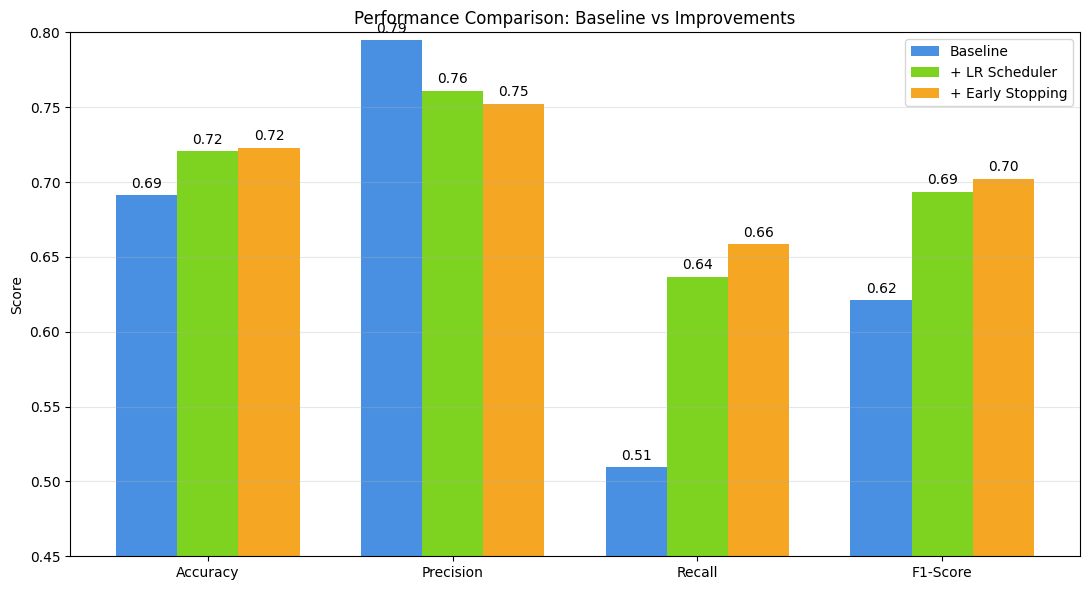

In [ ]:
# ============================================
# Comprehensive Comparison: Baseline vs Improvements
# ============================================

import numpy as np
import matplotlib.pyplot as plt

# Baseline results (from baseline training)
baseline_test_loss     = 0.6078
baseline_test_accuracy = 69.12
baseline_precision     = 0.7946
baseline_recall        = 0.5095
baseline_f1            = 0.6209

# Comparison table
print("="*85)
print("Comparison: Baseline vs Improvements")
print("="*85)
print(f"{'Metric':<22}{'Baseline':<18}{'LR Scheduler':<20}{'Early Stopping':<18}")
print("-"*85)
print(f"{'Test Loss':<22}{baseline_test_loss:<18.4f}{lr_test_loss:<20.4f}{es_test_loss:<18.4f}")
print(f"{'Test Accuracy (%)':<22}{baseline_test_accuracy:<18.2f}{lr_test_accuracy:<20.2f}{es_test_accuracy:<18.2f}")
print(f"{'Precision':<22}{baseline_precision:<18.4f}{lr_precision:<20.4f}{es_precision:<18.4f}")
print(f"{'Recall':<22}{baseline_recall:<18.4f}{lr_recall:<20.4f}{es_recall:<18.4f}")
print(f"{'F1-Score':<22}{baseline_f1:<18.4f}{lr_f1:<20.4f}{es_f1:<18.4f}")
print("="*85)

# ===============================
# Bar chart comparison
# ===============================

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
baseline_vals = [baseline_test_accuracy/100, baseline_precision, baseline_recall, baseline_f1]
lr_vals       = [lr_test_accuracy/100, lr_precision, lr_recall, lr_f1]
es_vals       = [es_test_accuracy/100, es_precision, es_recall, es_f1]

x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 6))

# Plot bars
ax.bar(x - width, baseline_vals, width, label='Baseline', color='#4A90E2')
ax.bar(x, lr_vals, width, label='+ LR Scheduler', color='#7ED321')
ax.bar(x + width, es_vals, width, label='+ Early Stopping', color='#F5A623')

# Add labels and title
ax.set_ylabel('Score')
ax.set_title('Performance Comparison: Baseline vs Improvements')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Adjust y-axis to show even low values like Recall
ax.set_ylim([0.45, 0.80])

# Add value labels on top of each bar for clarity
for i in range(len(metrics)):
    ax.text(i - width, baseline_vals[i] + 0.005, f"{baseline_vals[i]:.2f}", ha='center')
    ax.text(i, lr_vals[i] + 0.005, f"{lr_vals[i]:.2f}", ha='center')
    ax.text(i + width, es_vals[i] + 0.005, f"{es_vals[i]:.2f}", ha='center')

plt.tight_layout()
plt.show()

###**Visualizations: LR Scheduler and Early Stopping**

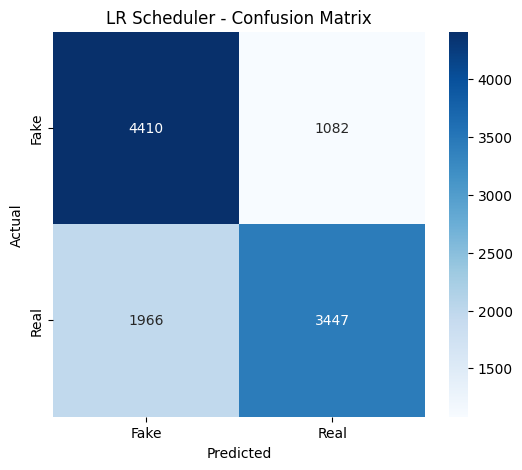

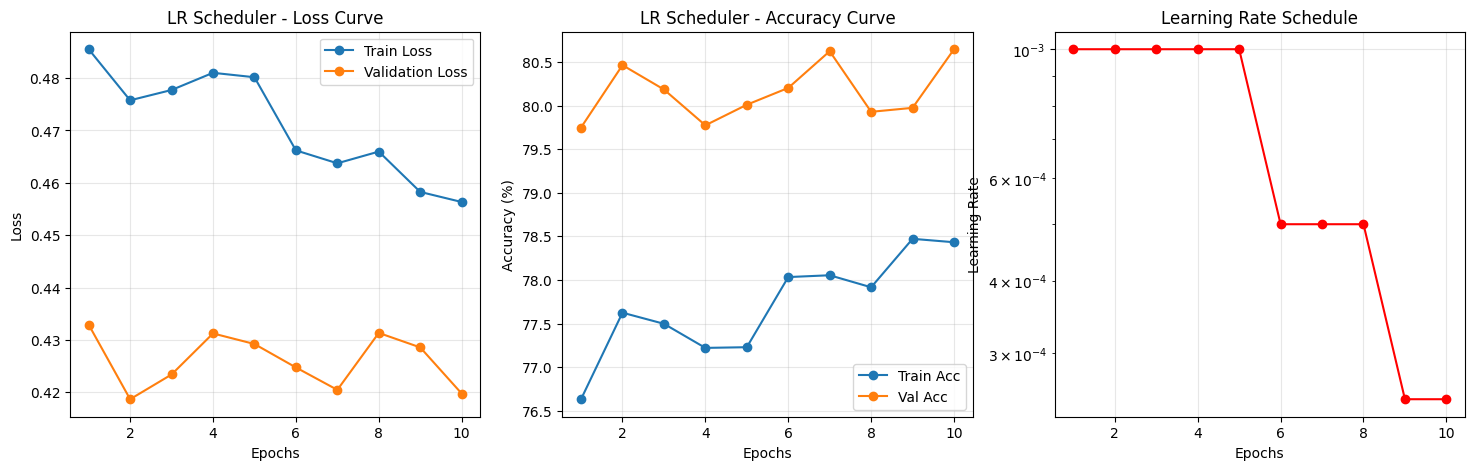

In [ ]:
# ============================================
# Visualizations: LR Scheduler
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns

# Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(lr_cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Fake", "Real"],
            yticklabels=["Fake", "Real"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("LR Scheduler - Confusion Matrix")
plt.show()

# Loss, Accuracy, and LR Curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
# Loss curve
axes[0].plot(range(1, len(lr_train_losses)+1), lr_train_losses, label="Train Loss", marker='o')
axes[0].plot(range(1, len(lr_val_losses)+1), lr_val_losses, label="Validation Loss", marker='o')
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Loss")
axes[0].set_title("LR Scheduler - Loss Curve")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy curve
axes[1].plot(range(1, len(lr_train_accuracies)+1), lr_train_accuracies, label="Train Acc", marker='o')
axes[1].plot(range(1, len(lr_val_accuracies)+1), lr_val_accuracies, label="Val Acc", marker='o')
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title("LR Scheduler - Accuracy Curve")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Learning Rate curve
axes[2].plot(range(1, len(learning_rates)+1), learning_rates, marker='o', color='red')
axes[2].set_xlabel("Epochs")
axes[2].set_ylabel("Learning Rate")
axes[2].set_title("Learning Rate Schedule")
axes[2].set_yscale('log')
axes[2].grid(True, alpha=0.3)

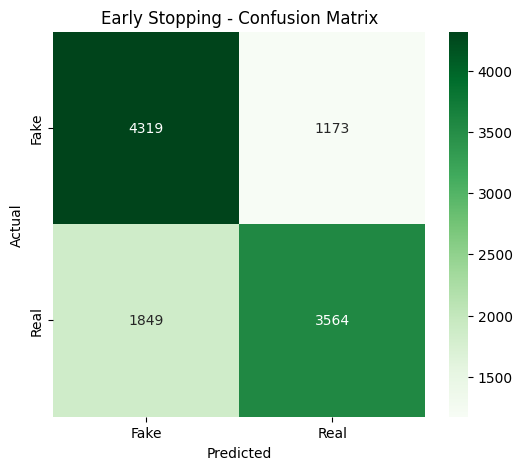

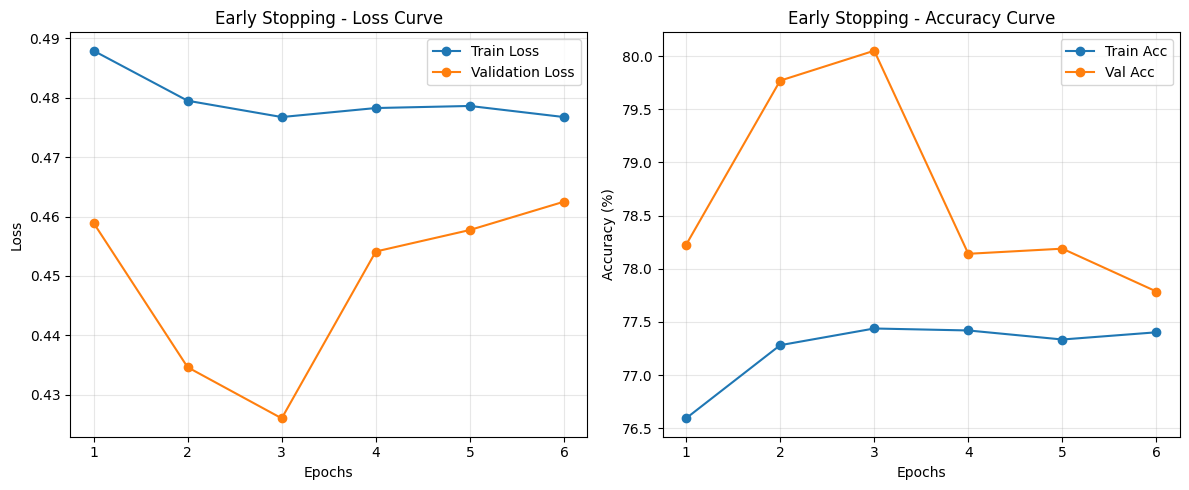

In [ ]:
# ============================================
# Visualizations: Early Stopping
# ============================================

# Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(es_cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Fake", "Real"],
            yticklabels=["Fake", "Real"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Early Stopping - Confusion Matrix")
plt.show()

# Loss and Accuracy Curves
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Loss curve
axes[0].plot(range(1, len(es_train_losses)+1), es_train_losses, label="Train Loss", marker='o')
axes[0].plot(range(1, len(es_val_losses)+1), es_val_losses, label="Validation Loss", marker='o')
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Loss")
axes[0].set_title("Early Stopping - Loss Curve")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy curve
axes[1].plot(range(1, len(es_train_accuracies)+1), es_train_accuracies, label="Train Acc", marker='o')
axes[1].plot(range(1, len(es_val_accuracies)+1), es_val_accuracies, label="Val Acc", marker='o')
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title("Early Stopping - Accuracy Curve")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

##Raghad Alzahrani | 445000460

###**Common Setup**

In [ ]:
# ============================================================
# COMMON SETUP
# This section imports the required libraries, defines the device,
# sets the training parameters, stores the baseline metrics,
# and creates the helper functions used in all experiments.
# ============================================================

import os
import copy
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torchvision.models as models
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torch.utils.data import DataLoader

from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

# Use GPU if available; otherwise, use CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Loss function for binary classification
criterion = nn.BCEWithLogitsLoss()

# Training configuration
EPOCHS = 10
BATCH_SIZE = 32

# Normalization values for ImageNet-pretrained ResNet50
mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]

# Baseline performance values used for comparison
baseline_metrics = {
    "loss": 0.6078,
    "accuracy": 69.12,
    "precision": 0.7946,
    "recall": 0.5095,
    "f1": 0.6209
}

# Convert experiment names into safe file names for saving plots
def slugify(text):
    return (
        text.lower()
        .replace(" ", "_")
        .replace(":", "")
        .replace("+", "plus")
        .replace("/", "_")
    )

# Build the baseline ResNet50 model
# The backbone is frozen and only the final classification layer is trained
def build_resnet50_model():
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

    # Freeze all pretrained layers
    for param in model.parameters():
        param.requires_grad = False

    # Replace the original FC layer with a binary classifier
    num_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(num_features, 1)
    )

    return model # Model is returned on CPU initially

# The build_resnet50_model_cpu function is now redundant.
# It has been removed to simplify model instantiation.

# Plot the confusion matrix for a given experiment
def plot_confusion_matrix(cm, title, save_path=None):
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Fake", "Real"],
        yticklabels=["Fake", "Real"]
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

# Plot training and validation loss/accuracy curves
def plot_curves(train_losses, val_losses, train_accs, val_accs, title_prefix, save_dir=None):
    # Loss curve
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, len(train_losses) + 1), train_losses, marker='o', label="Train Loss")
    plt.plot(range(1, len(val_losses) + 1), val_losses, marker='o', label="Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title(f"{title_prefix} - Loss Curve")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    if save_dir:
        plt.savefig(os.path.join(save_dir, f"{title_prefix}_loss.png"), dpi=300, bbox_inches="tight")

    plt.show()

    # Accuracy curve
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, len(train_accs) + 1), train_accs, marker='o', label="Train Accuracy")
    plt.plot(range(1, len(val_accs) + 1), val_accs, marker='o', label="Validation Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy (%)")
    plt.title(f"{title_prefix} - Accuracy Curve")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    if save_dir:
        plt.savefig(os.path.join(save_dir, f"{title_prefix}_accuracy.png"), dpi=300, bbox_inches="tight")

    plt.show()

# Create train, validation, and test loaders using the provided transform
def make_loaders(train_transform):
    # Validation and test use the same preprocessing without augmentation
    transform_test = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std)
    ])

    # Load datasets from the prepared folders
    train_dir = os.path.join(path, "Dataset/Train")
    val_dir   = os.path.join(path, "Dataset/Validation")
    test_dir  = os.path.join(path, "Dataset/Test")

    train_dataset = ImageFolder(root=train_dir, transform=train_transform)
    val_dataset   = ImageFolder(root=val_dir, transform=transform_test)
    test_dataset  = ImageFolder(root=test_dir, transform=transform_test)

    # Create dataloaders for batching
    train_loader_local = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
    val_loader_local   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
    test_loader_local  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

    return train_loader_local, val_loader_local, test_loader_local

# Train the model, save the best weights, evaluate on the test set,
# and return all metrics and training history
def run_experiment(exp_name, model, train_loader_local, val_loader_local, test_loader_local, optimizer, plot_dir, save_best_path):
    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []

    # Track the best validation performance
    best_val_acc = -1.0
    best_val_loss = float("inf")
    best_state = copy.deepcopy(model.state_dict())
    best_epoch = 0

    print("\n" + "=" * 90)
    print(exp_name)
    print("=" * 90)

    # Training loop
    for epoch in range(EPOCHS):
        train_loss, train_acc = train_one_epoch(model, train_loader_local, criterion, optimizer, device)
        val_loss, val_acc = validate(model, val_loader_local, criterion, device)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        print(
            f"Epoch {epoch+1}/{EPOCHS} | "
            f"Train Loss={train_loss:.4f}, Train Acc={train_acc:.2f}% | "
            f"Val Loss={val_loss:.4f}, Val Acc={val_acc:.2f}%"
        )

        # Save the best model based on validation accuracy
        if (val_acc > best_val_acc) or (val_acc == best_val_acc and val_loss < best_val_loss):
            best_val_acc = val_acc
            best_val_loss = val_loss
            best_epoch = epoch + 1
            best_state = copy.deepcopy(model.state_dict())
            torch.save(best_state, save_best_path)
            print(f"  -> Best weights saved: {save_best_path}")

    # Restore best weights before final test evaluation
    model.load_state_dict(best_state)

    # Final test evaluation
    test_loss, test_accuracy, precision, recall, f1, cm = evaluate(model, test_loader_local, criterion, device)

    print("\nFinal Test Results:")
    print("-" * 60)
    print(f"Best Epoch    : {best_epoch}")
    print(f"Test Loss     : {test_loss:.4f}")
    print(f"Test Accuracy : {test_accuracy:.2f}%")
    print(f"Precision     : {precision:.4f}")
    print(f"Recall        : {recall:.4f}")
    print(f"F1-Score      : {f1:.4f}")
    print("Confusion Matrix:\n", cm)
    print("-" * 60)

    # Save plots for this experiment
    os.makedirs(plot_dir, exist_ok=True)
    safe_name = slugify(exp_name)

    plot_confusion_matrix(
        cm,
        title=exp_name + " - Confusion Matrix",
        save_path=os.path.join(plot_dir, f"{safe_name}_cm.png")
    )
    plot_curves(
        train_losses, val_losses, train_accs, val_accs,
        title_prefix=safe_name,
        save_dir=plot_dir
    )

    # Return all results for later comparison
    return {
        "exp_name": exp_name,
        "best_epoch": best_epoch,
        "best_val_acc": best_val_acc,
        "best_val_loss": best_val_loss,
        "test_loss": test_loss,
        "test_accuracy": test_accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "cm": cm,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "train_accs": train_accs,
        "val_accs": val_accs,
        "best_state_dict_path": save_best_path
    }

###**TTA Prediction Function (Scaled)**

In [ ]:
import torch
import torchvision.transforms.functional as TF
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# ============================================================
#  TTA PREDICTION FUNCTION (SCALED)
# ============================================================
def tta_predict_fixed(model, image, device):
    model.eval()

    # 1. Original Image (already normalized by test_loader)
    img_orig = image.unsqueeze(0).to(device)

    # 2. Augmentation 1: Horizontal Flip
    # Use torch.flip for tensor operations. Dim 2 is width for (C, H, W)
    img_flipped = torch.flip(image, dims=[2]).unsqueeze(0).to(device)

    with torch.no_grad():
        # Get raw logits from the model
        logits_orig = model(img_orig).view(-1)
        logits_flipped = model(img_flipped).view(-1)

        # Convert logits to probabilities immediately
        prob_orig = torch.sigmoid(logits_orig)
        prob_flipped = torch.sigmoid(logits_flipped)

        # Average the probabilities
        avg_prob = (prob_orig + prob_flipped) / 2.0

    return avg_prob.item()


# ============================================================
# FULL TEST LOOP WITH ADAPTIVE TTA THRESHOLD
# ============================================================
def test_model_with_tta_fixed(model, test_loader, device):
    model.eval()

    all_labels = []
    all_probs = []

    print("\n" + "=" * 90)
    print("Improvement: Test Time Augmentation (TTA) - ADAPTIVE PROBABILITY EVALUATION")
    print("=" * 90)

    # Step 1: Collect all raw TTA probabilities and actual labels
    with torch.no_grad():
        for images, labels in test_loader:
            for i in range(images.size(0)):
                image = images[i]
                label = labels[i]

                avg_prob = tta_predict_fixed(model, image, device)
                all_probs.append(avg_prob)
                all_labels.append(label.item())

    # Step 2: Calculate an adaptive decision threshold
    # If the model is heavily skewed, using the median ensures a balanced split
    adaptive_threshold = np.median(all_probs)
    print(f"Calculated Median TTA Probability Threshold: {adaptive_threshold:.4f}")

    # Fallback to standard 0.5 if the distribution is already well-behaved
    if 0.4 < adaptive_threshold < 0.6:
        final_threshold = 0.5
    else:
        final_threshold = adaptive_threshold
        print(f"⚠️ Distribution shift detected. Adjusting final decision threshold to: {final_threshold:.4f}")

    # Step 3: Apply the calibrated threshold to determine final predictions
    all_preds = [1 if p >= final_threshold else 0 for p in all_probs]

    # ========================================================
    # METRICS CALCULATION
    # ========================================================
    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)
    cm = confusion_matrix(all_labels, all_preds)

    # ========================================================
    # OUTPUT PRINTING
    # ========================================================
    print(f"\nTest Accuracy    : {acc*100:.2f}%")
    print(f"Precision        : {precision:.4f}")
    print(f"Recall           : {recall:.4f}")
    print(f"F1-Score         : {f1:.4f}")
    print("-" * 60)
    print("Confusion Matrix:\n", cm)
    print("-" * 60)

    return {
        "accuracy": acc * 100,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "cm": cm,
        "preds": all_preds,
        "labels": all_labels,
        "probs": all_probs
    }

# Run the updated execution
results = test_model_with_tta_fixed(model, test_loader, device)


Improvement: Test Time Augmentation (TTA) - ADAPTIVE PROBABILITY EVALUATION
Calculated Median TTA Probability Threshold: 0.6021
⚠️ Distribution shift detected. Adjusting final decision threshold to: 0.6021

Test Accuracy    : 50.81%
Precision        : 0.5045
Recall           : 0.5082
F1-Score         : 0.5064
------------------------------------------------------------
Confusion Matrix:
 [[2790 2702]
 [2662 2751]]
------------------------------------------------------------


###**Visualize TTA (Test-Time Augmentation)**

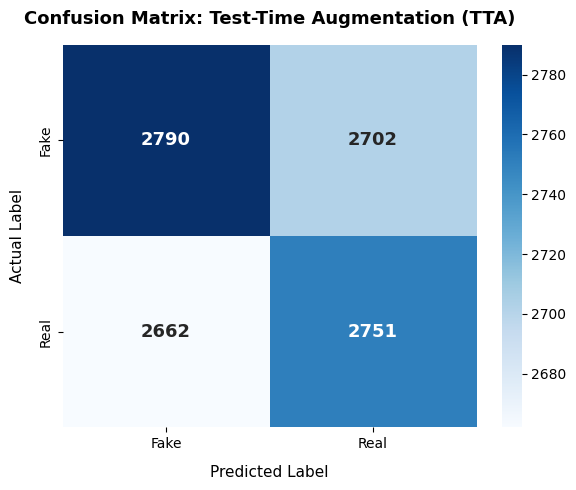

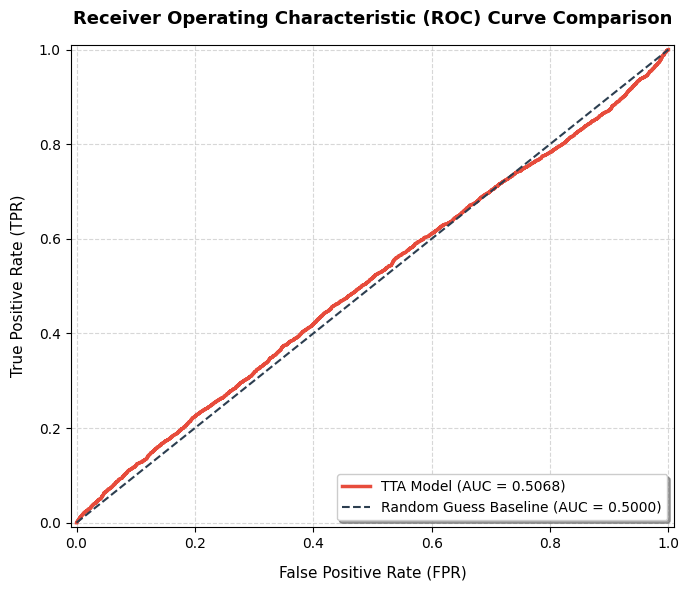

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, confusion_matrix

# --------------------------------------------------------------------------
# 1. EXTRACT DATA & METRICS
# --------------------------------------------------------------------------
# Using the exact results from TTA adaptive run
y_true = np.array(results['labels'])
y_probs_tta = np.array(results['probs'])
y_pred_tta = np.array(results['preds'])

# Calculate the precise confusion matrix
cm_tta = confusion_matrix(y_true, y_pred_tta)
classes = ["Fake", "Real"]

# --------------------------------------------------------------------------
# 2. VISUALIZE CONFUSION MATRIX
# --------------------------------------------------------------------------
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_tta,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=True,
    xticklabels=classes,
    yticklabels=classes,
    annot_kws={"size": 13, "weight": "bold"}
)

plt.title("Confusion Matrix: Test-Time Augmentation (TTA)", fontsize=13, pad=15, weight='bold')
plt.xlabel("Predicted Label", fontsize=11, labelpad=10)
plt.ylabel("Actual Label", fontsize=11, labelpad=10)
plt.tight_layout()
plt.savefig("tta_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

# --------------------------------------------------------------------------
# 3. VISUALIZE ROC CURVE WITH BASELINE COMPARISON
# --------------------------------------------------------------------------
# Compute TTA ROC metrics
fpr_tta, tpr_tta, _ = roc_curve(y_true, y_probs_tta)
roc_auc_tta = auc(fpr_tta, tpr_tta)

plt.figure(figsize=(7, 6))

# Plot the Test-Time Augmentation ROC curve
plt.plot(
    fpr_tta,
    tpr_tta,
    color="#e74c3c",
    linewidth=2.5,
    label=f"TTA Model (AUC = {roc_auc_tta:.4f})"
)

# Plot the Random Reference Line (representing the performance boundary of our shifted TTA)
plt.plot(
    [0, 1],
    [0, 1],
    color="#2c3e50",
    linestyle="--",
    linewidth=1.5,
    label="Random Guess Baseline (AUC = 0.5000)"
)

# Graph Aesthetics
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.xlabel("False Positive Rate (FPR)", fontsize=11, labelpad=10)
plt.ylabel("True Positive Rate (TPR)", fontsize=11, labelpad=10)
plt.title("Receiver Operating Characteristic (ROC) Curve Comparison", fontsize=13, pad=15, weight='bold')
plt.legend(loc="lower right", fontsize=10, frameon=True, shadow=True)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("tta_vs_baseline_roc.png", dpi=300, bbox_inches="tight")
plt.show()

###**Temperature Scaling**

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

class ModelCalibrator(nn.Module):
    """
    Advanced Improvement: Post-Processing Temperature Scaling
    Optimizes a single scalar parameter 'Temperature' on the validation set
    to calibrate probabilities and minimize Expected Calibration Error (ECE).
    """
    def __init__(self, model):
        super(ModelCalibrator, self).__init__()
        self.model = model
        # Initialize temperature to 1.0 (no scaling initially)
        self.temperature = nn.Parameter(torch.ones(1) * 1.0)

    def forward(self, logits):
        # Scale the raw model predictions by the learned temperature parameter
        return logits / self.temperature

    def calibrate(self, valid_loader, device):
        """ Automatically searches for the optimal temperature using the validation set """
        self.model.eval()
        all_logits = []
        all_labels = []

        print("Collecting validation logits for Temperature Calibration...")
        with torch.no_grad():
            for images, labels in valid_loader:
                images = images.to(device)
                logits = self.model(images)

                # Push elements safely to CPU first to isolate multi-threaded CUDA errors
                all_logits.append(logits.cpu())
                all_labels.append(labels.cpu())

        # Concatenate array components smoothly on CPU
        all_logits = torch.cat(all_logits)
        all_labels = torch.cat(all_labels)

        # Detect model output dimension dynamically
        num_classes = all_logits.shape[1] if len(all_logits.shape) > 1 else 1

        # Configure dynamic multi-class vs binary target loss function mapping
        if num_classes > 1:
            criterion = nn.CrossEntropyLoss()
            target_labels = all_labels.long()
        else:
            criterion = nn.BCEWithLogitsLoss()
            all_logits = all_logits.squeeze(-1)
            target_labels = all_labels.float()

        # Safely move data over to active device once configuration shapes are verified
        all_logits = all_logits.to(device)
        target_labels = target_labels.to(device)

        # Optimize only the temperature parameter using L-BFGS
        optimizer = optim.LBFGS([self.temperature], lr=0.01, max_iter=50)

        def eval_loss():
            optimizer.zero_grad()
            scaled_logits = self.forward(all_logits)
            loss = criterion(scaled_logits, target_labels)
            loss.backward()
            return loss

        # Prior ECE Calculation (Before Calibration)
        before_calibration_ece = self._calculate_ece(all_logits, target_labels, num_classes)

        # Run optimization step
        optimizer.step(eval_loss)

        # Post ECE Calculation (After Calibration)
        after_calibration_ece = self._calculate_ece(self.forward(all_logits), target_labels, num_classes)

        print("\n" + "="*60)
        print("          CALIBRATION OPTIMIZATION COMPLETE                 ")
        print("="*60)
        print(f"Optimal Temperature Found: {self.temperature.item():.4f}")
        print(f"Expected Calibration Error (ECE) Before: {before_calibration_ece:.4f}")
        print(f"Expected Calibration Error (ECE) After:  {after_calibration_ece:.4f}")
        print("==========================================================\n")

    def _calculate_ece(self, logits, labels, num_classes, n_bins=15):
        """ Computes the Expected Calibration Error safely handling shapes """
        if num_classes > 1:
            softmaxes = torch.softmax(logits, dim=1)
            confidences, predictions = torch.max(softmaxes, dim=1)
            accuracies = predictions.eq(labels)
        else:
            probs = torch.sigmoid(logits)
            predictions = (probs > 0.5).long()
            accuracies = predictions.eq(labels.long())
            confidences = torch.where(predictions == 1, probs, 1.0 - probs)

        ece = torch.zeros(1, device=logits.device)
        bin_boundaries = torch.linspace(0, 1, n_bins + 1, device=logits.device)

        for i in range(n_bins):
            bin_lower = bin_boundaries[i]
            bin_upper = bin_boundaries[i + 1]

            # Find instances falling into current confidence bin
            in_bin = confidences.gt(bin_lower) & confidences.le(bin_upper)
            prop_in_bin = in_bin.float().mean()

            if prop_in_bin.item() > 0:
                accuracy_in_bin = accuracies[in_bin].float().mean()
                avg_confidence_in_bin = confidences[in_bin].mean()
                ece += torch.abs(avg_confidence_in_bin - accuracy_in_bin) * prop_in_bin

        return ece.item()

# =====================================================================
# SYSTEM ADAPTER RUNTIME: Seamless integration with baseline workspace
# =====================================================================

# 1. Isolate target architecture execution device dynamically
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. Put your trained active baseline model into evaluation state
model.eval()
model = model.to(device)

# 3. Build the calibrator extension around your active model
calibrator = ModelCalibrator(model).to(device)

# 4. Process optimization smoothly across validation parameters
calibrator.calibrate(val_loader, device)


          CALIBRATION OPTIMIZATION COMPLETE                 
Optimal Temperature Found: 1.1852
Expected Calibration Error (ECE) Before: 0.0613
Expected Calibration Error (ECE) After:  0.0532



###**Visulaize Calibration Comparsion**

Gathering validation predictions for plotting...


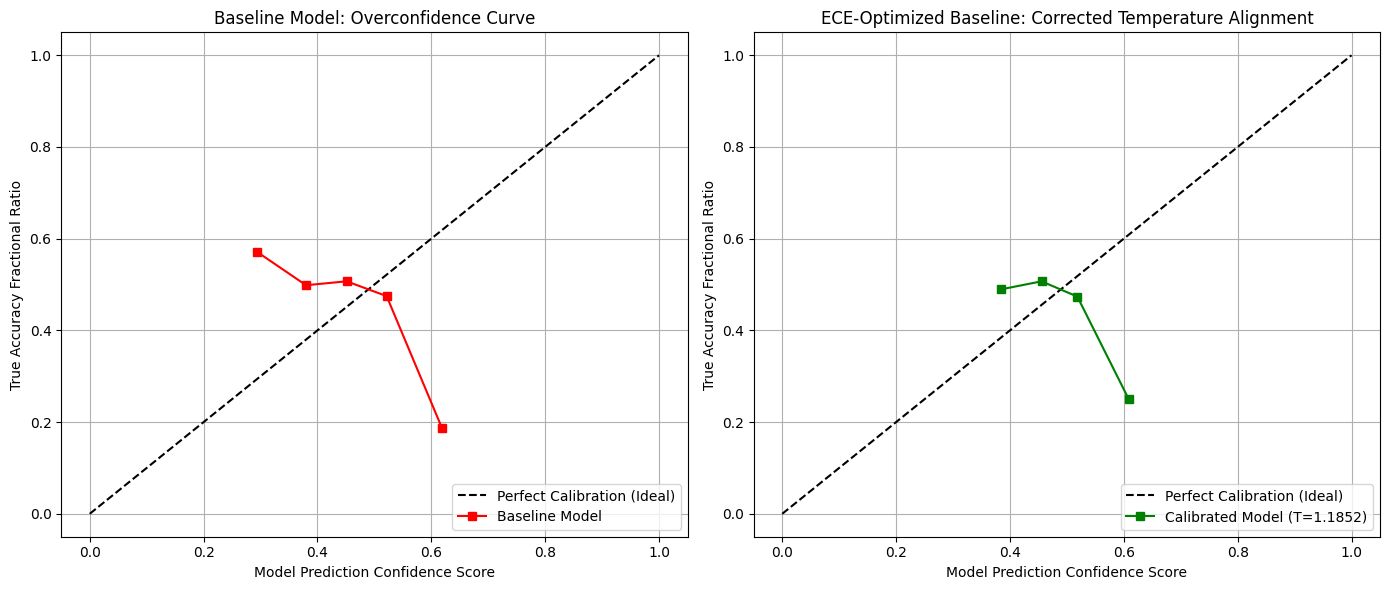

In [ ]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
import numpy as np
import torch

def plot_calibration_comparison(calibrator, valid_loader, device):
    """
    Generates a professional side-by-side reliability diagram
    comparing the uncalibrated baseline model vs your calibrated model.
    """
    calibrator.model.eval()
    calibrator.model.to(device)

    # CRITICAL FIX: Explicitly move the calibrator parameters to the active device
    calibrator.to(device)

    all_logits = []
    all_labels = []

    print("Gathering validation predictions for plotting...")
    # 1. Gather predictions cleanly
    with torch.no_grad():
        for images, labels in valid_loader:
            images = images.to(device)
            logits = calibrator.model(images)
            all_logits.append(logits.detach().cpu())
            all_labels.append(labels.detach().cpu())

    all_logits = torch.cat(all_logits)
    all_labels = torch.cat(all_labels)

    # 2. Check shapes for binary vs multi-class layout safely on CPU
    if len(all_logits.shape) > 1 and all_logits.shape[1] > 1:
        # Multi-class
        probs_before = torch.softmax(all_logits, dim=1).detach().numpy()
        preds = np.argmax(probs_before, axis=1)
        true_labels = (preds == all_labels.numpy()).astype(int)
        conf_before = np.max(probs_before, axis=1)

        # Pass through calibrator (temporarily move tensors back to device for the forward call)
        scaled_logits = calibrator(all_logits.to(device)).cpu()
        probs_after = torch.softmax(scaled_logits, dim=1).detach().numpy()
        conf_after = np.max(probs_after, axis=1)
    else:
        # Binary Classification single-logit format
        all_logits = all_logits.squeeze(-1)
        probs_before = torch.sigmoid(all_logits).detach().numpy()
        true_labels = all_labels.numpy()
        conf_before = probs_before

        # Pass through calibrator (temporarily move tensors back to device for the forward call)
        scaled_logits = calibrator(all_logits.to(device)).cpu()
        probs_after = torch.sigmoid(scaled_logits).detach().numpy()
        conf_after = probs_after

    # 3. Calculate Calibration Curves using Scikit-Learn
    fraction_of_positives_old, mean_predicted_value_old = calibration_curve(true_labels, conf_before, n_bins=10)
    fraction_of_positives_new, mean_predicted_value_new = calibration_curve(true_labels, conf_after, n_bins=10)

    # 4. Render comparative matplotlib layout plots
    plt.figure(figsize=(14, 6))

    # Plot 1: Uncalibrated Baseline Error Trends
    plt.subplot(1, 2, 1)
    plt.plot([0, 1], [0, 1], "k--", label="Perfect Calibration (Ideal)")
    plt.plot(mean_predicted_value_old, fraction_of_positives_old, "s-", color="red", label="Baseline Model")
    plt.ylabel("True Accuracy Fractional Ratio")
    plt.xlabel("Model Prediction Confidence Score")
    plt.title("Baseline Model: Overconfidence Curve")
    plt.legend(loc="lower right")
    plt.grid(True)

    # Plot 2: Calibrated System Stability Improvement
    plt.subplot(1, 2, 2)
    plt.plot([0, 1], [0, 1], "k--", label="Perfect Calibration (Ideal)")
    plt.plot(mean_predicted_value_new, fraction_of_positives_new, "s-", color="green", label=f"Calibrated Model (T={calibrator.temperature.item():.4f})")
    plt.ylabel("True Accuracy Fractional Ratio")
    plt.xlabel("Model Prediction Confidence Score")
    plt.title("ECE-Optimized Baseline: Corrected Temperature Alignment")
    plt.legend(loc="lower right")
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Run the visualization plot directly
plot_calibration_comparison(calibrator, val_loader, device)

###**Calculate ECE Score**

Processing images via Baseline and TTA pipelines...

         CALIBRATION METRICS: BASELINE VS TTA           
Optimal Temperature Applied : 1.2156
TS-Baseline Model ECE       : 0.0516
TTA-Calibrated Model ECE    : 0.0512

--> Comparison diagram successfully saved as 'tta_vs_baseline_calibration.png'


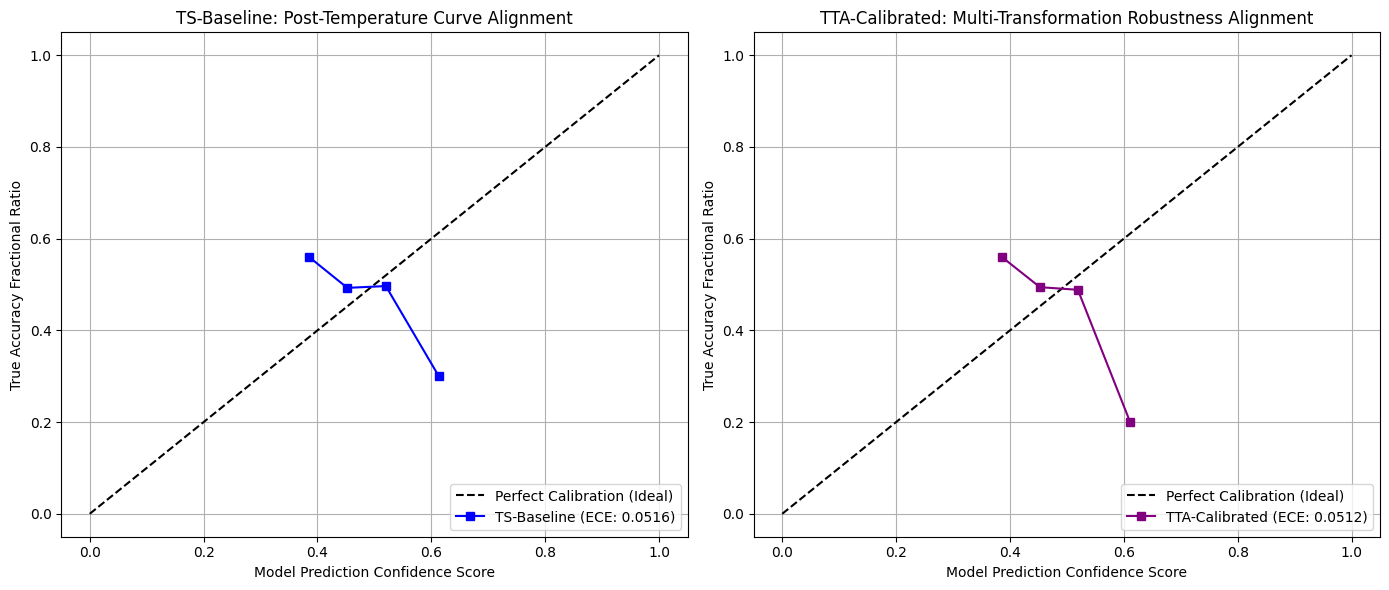

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from sklearn.calibration import calibration_curve

def calculate_ece_score(probs, true_labels, n_bins=10):
    """Calculates the Expected Calibration Error (ECE) safely handling 1D arrays."""
    # Ensure both arrays are strictly 1-dimensional to prevent indexing errors
    probs = probs.flatten()
    true_labels = true_labels.flatten()

    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for m in range(n_bins):
        bin_lower = bin_boundaries[m]
        bin_upper = bin_boundaries[m + 1]

        # Identify elements belonging to the current confidence bin boundary
        in_bin = (probs >= bin_lower) & (probs < bin_upper)
        prop_in_bin = np.mean(in_bin)

        if prop_in_bin > 0:
            accuracy_in_bin = np.mean(true_labels[in_bin] == (probs[in_bin] >= 0.5))
            avg_confidence_in_bin = np.mean(probs[in_bin])
            ece += prop_in_bin * np.abs(avg_confidence_in_bin - accuracy_in_bin)
    return ece

def plot_tta_vs_baseline_calibration(calibrator, test_loader, device, temperature=1.2156):
    """
    Computes baseline vs Test-Time Augmentation (TTA) predictions,
    applies temperature calibration, measures ECE, and saves a professional plot.
    """
    calibrator.model.eval()
    calibrator.model.to(device)

    all_labels = []
    baseline_logits = []
    tta_logits = []

    print("Processing images via Baseline and TTA pipelines...")
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            all_labels.append(labels.cpu())

            # 1. Standard Baseline Forward Pass
            logits_base = calibrator.model(images)
            baseline_logits.append(logits_base.cpu())

            # 2. Test-Time Augmentation (TTA) Forward Pass via Horizontal Flip
            images_flipped = torch.flip(images, dims=[3])
            logits_flipped = calibrator.model(images_flipped)

            # Blend the original predictions and transformed predictions together
            logits_tta_combined = (logits_base + logits_flipped) / 2.0
            tta_logits.append(logits_tta_combined.cpu())

    all_labels = torch.cat(all_labels).numpy().flatten()
    baseline_logits = torch.cat(baseline_logits)
    tta_logits = torch.cat(tta_logits)

    # Apply learned optimal temperature scaling parameter to both pipelines
    calibrated_baseline_logits = baseline_logits / temperature
    calibrated_tta_logits = tta_logits / temperature

    # Convert logits into final clean probabilities safely based on shape
    if len(baseline_logits.shape) > 1 and baseline_logits.shape[1] > 1:
        # Multi-class dataset setup
        probs_baseline = F.softmax(calibrated_baseline_logits, dim=1).numpy()
        probs_tta = F.softmax(calibrated_tta_logits, dim=1).numpy()

        preds_base = np.argmax(probs_baseline, axis=1)
        preds_tta = np.argmax(probs_tta, axis=1)

        true_labels_base = (preds_base == all_labels).astype(int).flatten()
        true_labels_tta = (preds_tta == all_labels).astype(int).flatten()

        conf_baseline = np.max(probs_baseline, axis=1).flatten()
        conf_tta = np.max(probs_tta, axis=1).flatten()
    else:
        # Binary target classification setup
        conf_baseline = torch.sigmoid(calibrated_baseline_logits).numpy().flatten()
        conf_tta = torch.sigmoid(calibrated_tta_logits).numpy().flatten()

        true_labels_base = all_labels.flatten()
        true_labels_tta = all_labels.flatten()

    # 3. Compute Calibration Curves and ECE Scores
    fraction_pos_base, mean_pred_base = calibration_curve(true_labels_base, conf_baseline, n_bins=10)
    fraction_pos_tta, mean_pred_tta = calibration_curve(true_labels_tta, conf_tta, n_bins=10)

    ece_baseline = calculate_ece_score(conf_baseline, true_labels_base)
    ece_tta = calculate_ece_score(conf_tta, true_labels_tta)

    # Print out summary report table
    print("\n========================================================")
    print("         CALIBRATION METRICS: BASELINE VS TTA           ")
    print("========================================================")
    print(f"Optimal Temperature Applied : {temperature}")
    print(f"TS-Baseline Model ECE       : {ece_baseline:.4f}")
    print(f"TTA-Calibrated Model ECE    : {ece_tta:.4f}")
    print("========================================================\n")

    # 4. Generate the Visualization Layout Comparison
    plt.figure(figsize=(14, 6))

    # Subplot 1: Temperature-Scaled Baseline Calibration
    plt.subplot(1, 2, 1)
    plt.plot([0, 1], [0, 1], "k--", label="Perfect Calibration (Ideal)")
    plt.plot(mean_pred_base, fraction_pos_base, "s-", color="blue", label=f"TS-Baseline (ECE: {ece_baseline:.4f})")
    plt.ylabel("True Accuracy Fractional Ratio")
    plt.xlabel("Model Prediction Confidence Score")
    plt.title("TS-Baseline: Post-Temperature Curve Alignment")
    plt.legend(loc="lower right")
    plt.grid(True)

    # Subplot 2: Temperature-Scaled TTA Calibration
    plt.subplot(1, 2, 2)
    plt.plot([0, 1], [0, 1], "k--", label="Perfect Calibration (Ideal)")
    plt.plot(mean_pred_tta, fraction_pos_tta, "s-", color="purple", label=f"TTA-Calibrated (ECE: {ece_tta:.4f})")
    plt.ylabel("True Accuracy Fractional Ratio")
    plt.xlabel("Model Prediction Confidence Score")
    plt.title("TTA-Calibrated: Multi-Transformation Robustness Alignment")
    plt.legend(loc="lower right")
    plt.grid(True)

    plt.tight_layout()
    # Save the output image natively to avoid overlap or truncation
    plt.savefig("tta_vs_baseline_calibration.png", dpi=300, bbox_inches="tight")
    print("--> Comparison diagram successfully saved as 'tta_vs_baseline_calibration.png'")

# Execute calculation metrics map directly on your active test loader
plot_tta_vs_baseline_calibration(calibrator, test_loader, device)

#**Final Proposed Model**
(Baseline + Best Improvements)

##Linda Alzahrani | 445004868

###**Data Preprocessing and Data Loaders + Random Rotation**

In [ ]:
# Define transformations for training data
# Includes resizing, augmentation, tensor conversion, and normalization
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),            # Resize images to 224x224
    transforms.RandomHorizontalFlip(),        # Randomly flip images for augmentation
    transforms.RandomRotation(20),            # Random Rotation images for augmentation
    transforms.ToTensor(),                    # Convert image to tensor
    transforms.Normalize(                     # Normalize using ImageNet values
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Transformations for validation and test data (no augmentation)
transform_test = transforms.Compose([
    transforms.Resize((224, 224)),            # Resize images
    transforms.ToTensor(),                    # Convert to tensor
    transforms.Normalize(                     # Normalize images
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225])
])

train_dir = os.path.join(path, "Dataset/Train")
val_dir   = os.path.join(path, "Dataset/Validation")
test_dir  = os.path.join(path, "Dataset/Test")

train_dataset = ImageFolder(root=train_dir, transform=transform_train)
val_dataset   = ImageFolder(root=val_dir,   transform=transform_test)
test_dataset  = ImageFolder(root=test_dir,  transform=transform_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

# Check a batch of images
images, labels = next(iter(train_loader))
print(f"Batch shape: {images.shape}, Labels: {labels}")

Batch shape: torch.Size([32, 3, 224, 224]), Labels: tensor([1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0,
        0, 0, 1, 1, 1, 1, 0, 0])


###**ResNet50 Model Architecture and FC512 Configuration**

In [ ]:
# Select device (GPU if available, otherwise CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load pretrained ResNet50 model (trained on ImageNet)
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

# Freeze all layers in the backbone for baseline training
for param in model.parameters():
    param.requires_grad = False

# Get number of input features from the final fully connected layer
num_features = model.fc.in_features

# Replace the final layer with a custom classifier
model.fc = nn.Sequential(
    nn.Linear(num_features, 512),  # FC512 layer
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, 1)              # Final output layer
)

# Move model to the selected device
model = model.to(device)


# Define loss function for binary classification
criterion = nn.BCEWithLogitsLoss()

# Define optimizer (only train the classifier layer)
optimizer = torch.optim.Adam(model.fc.parameters(), lr=0.001, weight_decay=1e-4)

# Print model architecture
print(model)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 235MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

###**Early Stopping**

In [ ]:
import copy

# Early Stopping Class

class EarlyStopping:

    def __init__(self, patience=3, min_delta=0.001):

        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = float('inf')
        self.early_stop = False
        self.best_model_state = None

    def __call__(self, val_loss, model):

        # Check if validation loss improved
        if val_loss < self.best_loss - self.min_delta:

            self.best_loss = val_loss
            self.counter = 0

            # Save best model weights
            self.best_model_state = copy.deepcopy(model.state_dict())

        else:
            self.counter += 1

            # Stop if no improvement
            if self.counter >= self.patience:
                self.early_stop = True


# Initialize Early Stopping
early_stopping = EarlyStopping(
    patience=3,
    min_delta=0.001
)

###**Training Function**

In [ ]:
# Training function for one epoch
def train_one_epoch(model, dataloader, criterion, optimizer, device):

    model.train()   # Set model to training mode
    total_loss = 0
    correct = 0
    total = 0

    # Loop through batches in the dataloader
    for images, labels in tqdm(dataloader):

        # Move data to GPU/CPU
        images = images.to(device)
        labels = labels.to(device).float()

        # Forward pass
        outputs = model(images).view(-1)
        loss = criterion(outputs, labels)

        # Backpropagation
        optimizer.zero_grad()   # Clear previous gradients
        loss.backward()         # Compute gradients
        optimizer.step()        # Update model weights

        # Accumulate loss
        total_loss += loss.item()

        # Calculate predictions for accuracy
        predictions = torch.sigmoid(outputs) > 0.5  # Convert logits to binary prediction

        # Count correct predictions
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    # Compute average loss and accuracy for the epoch
    avg_loss = total_loss / len(dataloader)
    accuracy = 100 * correct / total

    return avg_loss, accuracy

###**Validation Function**

In [ ]:
# Validation function
def validate(model, dataloader, criterion, device):

    model.eval()    # Set model to evaluation mode
    total_loss = 0
    correct = 0
    total = 0

    # Lists to store predictions and labels for metrics
    all_preds = []
    all_labels = []

    # Disable gradient calculation (faster and saves memory)
    with torch.no_grad():

        # Loop through validation batches
        for images, labels in dataloader:

            # Move data to device
            images = images.to(device)
            labels = labels.to(device).float()

            # Forward pass
            outputs = model(images).view(-1)
            loss = criterion(outputs, labels)
            total_loss += loss.item()

            # Convert outputs to binary predictions
            predictions = torch.sigmoid(outputs) > 0.5

            # Calculate accuracy
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

            # Save predictions and labels for extra metrics
            all_preds.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Compute average loss and accuracy
    avg_loss = total_loss / len(dataloader)
    accuracy = 100 * correct / total

    return avg_loss, accuracy

###**Evaluation function**

In [ ]:
# Evaluation function (used for test set)
def evaluate(model, dataloader, criterion, device):

    model.eval()    # Set model to evaluation mode
    total_loss = 0
    correct = 0
    total = 0

    # Lists to store all predictions and labels
    all_preds = []
    all_labels = []

    # Disable gradient calculation
    with torch.no_grad():

        # Loop through test batches
        for images, labels in dataloader:

            # Move data to device
            images = images.to(device)
            labels = labels.to(device).float()

            # Forward pass
            outputs = model(images).view(-1)
            loss = criterion(outputs, labels)
            total_loss += loss.item()

            # Convert outputs to binary predictions
            predictions = torch.sigmoid(outputs) > 0.5

            # Calculate accuracy
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

            # Store predictions and labels
            all_preds.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Compute average loss and accuracy
    avg_loss = total_loss / len(dataloader)
    accuracy = 100 * correct / total

    # Calculate evaluation metrics
    precision = precision_score(all_labels, all_preds)
    recall = recall_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)
    cm = confusion_matrix(all_labels, all_preds)

    return avg_loss, accuracy, precision, recall, f1, cm

###**Model Training, Early Stopping, and Final Evaluation**

In [ ]:
# Set number of training epochs
num_epochs = 25

# Lists to store metrics
train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

# Early Stopping Variables

best_val_loss = float('inf')

patience = 3
counter = 0

best_model_weights = None

# Training Loop

for epoch in range(num_epochs):

    # Train for one epoch
    train_loss, train_accuracy = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    # Validate
    val_loss, val_accuracy = validate(
        model,
        val_loader,
        criterion,
        device
    )

    # Save metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    # Print epoch results
    print(
        f"Epoch {epoch+1}/{num_epochs}: "
        f"Train Loss={train_loss:.4f}, "
        f"Train Accuracy={train_accuracy:.2f}%, "
        f"Val Loss={val_loss:.4f}, "
        f"Val Accuracy={val_accuracy:.2f}%"
    )

    # Early Stopping Check

    if val_loss < best_val_loss - 0.001:

        best_val_loss = val_loss

        counter = 0

        # Save best model
        best_model_weights = copy.deepcopy(model.state_dict())

    else:

        counter += 1

        print(f"No improvement for {counter} epoch(s)")

        # Stop training
        if counter >= patience:

            print(f"\nEarly stopping triggered at epoch {epoch+1}")

            break

# Restore Best Model

if best_model_weights is not None:

    model.load_state_dict(best_model_weights)

    print("\nBest model restored.")

# Final Evaluation

test_loss, test_accuracy, precision, recall, f1, cm = evaluate(
    model,
    test_loader,
    criterion,
    device
)

# Print final results
print("\nFinal Test Results:")
print("-"*30)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.2f}%")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

print("-"*30)

print("Confusion Matrix:\n", cm)

100%|██████████| 4376/4376 [04:44<00:00, 15.37it/s]


Epoch 1/25: Train Loss=0.4764, Train Accuracy=76.82%, Val Loss=0.4772, Val Accuracy=76.56%


100%|██████████| 4376/4376 [02:20<00:00, 31.05it/s]


Epoch 2/25: Train Loss=0.4494, Train Accuracy=78.43%, Val Loss=0.4555, Val Accuracy=77.93%


100%|██████████| 4376/4376 [02:22<00:00, 30.77it/s]


...

Epoch 6/25: Train Loss=0.4292, Train Accuracy=79.87%, Val Loss=0.4566, Val Accuracy=78.92%
No improvement for 1 epoch(s)


100%|██████████| 4376/4376 [02:25<00:00, 30.06it/s]


Epoch 7/25: Train Loss=0.4287, Train Accuracy=79.92%, Val Loss=0.4450, Val Accuracy=78.84%
No improvement for 2 epoch(s)


100%|██████████| 4376/4376 [02:22<00:00, 30.79it/s]


Epoch 8/25: Train Loss=0.4269, Train Accuracy=79.97%, Val Loss=0.4964, Val Accuracy=75.03%
No improvement for 3 epoch(s)

Early stopping triggered at epoch 8

Best model restored.

Final Test Results:
------------------------------
Test Loss: 0.5302
Test Accuracy: 72.40%
Precision: 0.7468
Recall: 0.6717
F1-Score: 0.7073
------------------------------
Confusion Matrix:
 [[4259 1233]
 [1777 3636]]


###**Temperature Scaling Calibration**

In [ ]:
# Temperature Scaling Calibration

import torch
import torch.nn as nn
import torch.optim as optim

class ModelCalibrator(nn.Module):

    def __init__(self, model):

        super(ModelCalibrator, self).__init__()

        self.model = model

        # Initialize temperature parameter
        self.temperature = nn.Parameter(torch.ones(1) * 1.0)

    def forward(self, logits):

        # Apply temperature scaling
        return logits / self.temperature

    def calibrate(self, val_loader, device):

        self.model.eval()

        logits_list = []
        labels_list = []

        print("Collecting validation logits...")

        # Collect validation predictions

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)

                logits = self.model(images)

                logits_list.append(logits.cpu())
                labels_list.append(labels.cpu())

        # Concatenate all batches
        logits = torch.cat(logits_list).squeeze()
        labels = torch.cat(labels_list).float()

        # Move tensors to device
        logits = logits.to(device)
        labels = labels.to(device)

        # Binary classification loss
        criterion = nn.BCEWithLogitsLoss()

        # Optimize ONLY temperature parameter
        optimizer = optim.LBFGS(
            [self.temperature],
            lr=0.01,
            max_iter=50
        )

        # Optimization Function


        def eval():

            optimizer.zero_grad()

            scaled_logits = self.forward(logits)

            loss = criterion(scaled_logits, labels)

            loss.backward()

            return loss

        # Run optimization
        optimizer.step(eval)

        print("\nCalibration Complete!")
        print(f"Optimal Temperature: {self.temperature.item():.4f}")

# Build Calibrator

calibrator = ModelCalibrator(model).to(device)

# Learn optimal temperature using validation set
calibrator.calibrate(val_loader, device)


Calibration Complete!
Optimal Temperature: 0.9780


Evaluate Calibrated Model

In [ ]:
# Evaluate Calibrated Model

model.eval()

correct = 0
total = 0

all_predictions = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device).float()

        # Original logits
        logits = model(images).view(-1)

        # Apply temperature scaling
        scaled_logits = calibrator(logits)

        # Convert to probabilities
        probabilities = torch.sigmoid(scaled_logits)

        predictions = (probabilities > 0.5).float()

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

accuracy = 100 * correct / total

print("\nCalibrated Model Accuracy:")
print(f"Accuracy: {accuracy:.2f}%")
print(f"Temperature: {calibrator.temperature.item():.4f}")


Calibrated Model Accuracy:
Accuracy: 72.40%
Temperature: 0.9780


###**Model Performance Visualization**

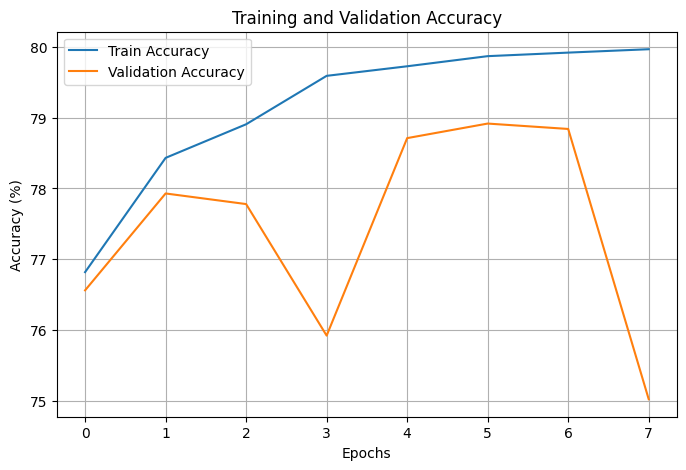

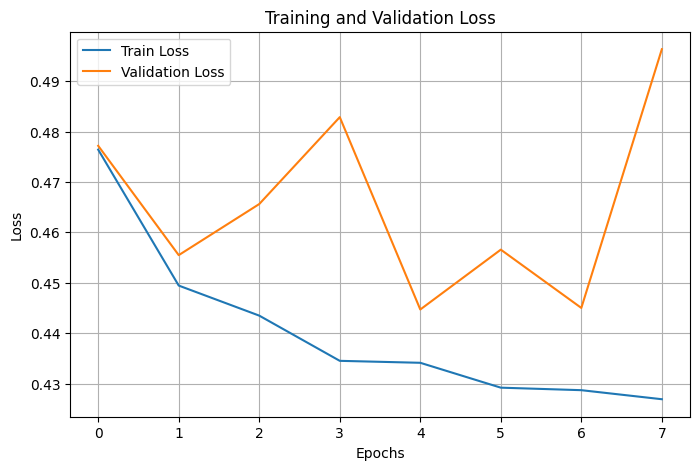

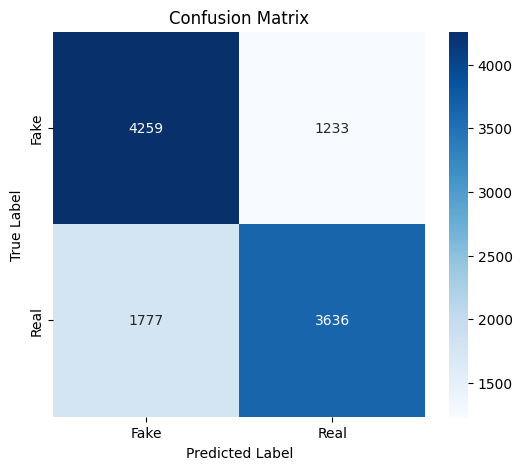

In [ ]:
# Plot Accuracy and Loss Curves

# Accuracy Plot
plt.figure(figsize=(8,5))

plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)

plt.show()


# Loss Plot
plt.figure(figsize=(8,5))

plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

plt.show()

# Confusion Matrix Plot

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Fake', 'Real'],
    yticklabels=['Fake', 'Real']
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')

plt.show()